# DD2437 LAB1


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1090)#lols

# constants
EPOCHS = 100
N = 100
LR = 0.001
LRs = [0.00001, 0.0001, 0.001, 0.005]

## Reusable functions

In [2]:
def get_initial_weights(size, variance):
    """Returns base weights and weights with an additional bias column.

    Args:
        size (tuple of int): The shape (rows, cols) of the base weight array.
        variance (float): The variance of the normal distribution.

    Returns:
        tuple (np.ndarray, np.ndarray):
            - base_weights: Matrix with original shape `size`.
            - biased_weights: Matrix with shape `(size[0], size[1] + 1)` sharing
              identical base weights plus an appended bias column.
    """
    std_dev = np.sqrt(variance)

    base_weights = np.random.normal(loc=0.0, scale=std_dev, size=size)

    bias_col = np.random.normal(loc=0.0, scale=std_dev, size=(size[0], 1))
    biased_weights = np.hstack([base_weights, bias_col])

    return base_weights, biased_weights

In [3]:
def plot_learning_curve(error_history, xlabel, ylabel, ax=None):
  """
  Plots learning curve of missclasifications or error history over epochs.

  Args:
      error_history (np.ndarray): Array of error values or number of missclassifications over epochs.
      xlabel (str): Label for the x-axis.
      ylabel (str): Label for the y-axis.
      ax (matplotlib.axes.Axes, optional): Axes to plot on. Defaults to None.
  """
  if ax is None:
      ax = plt.gca()

  ax.plot(error_history)
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  ax.set_xlim(0)
  ax.set_ylim(0)
  ax.set_title("Learning curve")

In [4]:
def plot_decision_boundary(weights, features, labels, title, ax=None, bias=True):

  if ax is None:
        ax = plt.gca()

  ax.scatter(features[0, labels == -1], features[1, labels == -1], color="red", alpha=0.6)
  ax.scatter(features[0, labels == 1], features[1, labels == 1], color="blue", alpha=0.6)

  w0 = weights[0][0]
  w1 = weights[0][1]
  w_bias = 0
  if bias: 
    w_bias = weights[0][2]

  x1 = np.array([-5, 5])
  x2 = -(w0 * x1 + w_bias) / w1

  ax.plot(x1, x2, color="black")
  ax.set_ylim(-1.75, 1.75)
  ax.set_xlim(-1.75, 1.75)
  ax.set_title(title)
  ax.grid(True, linestyle="--", alpha=0.6)

In [5]:
import numpy as np


def generate_data_clouds(N, mA, mB, sigmaA, sigmaB):
    """
    Generates linearly separable 2D data for two classes drawn from normal distributions.
    Args:
        N (int): Number of samples to generate for each class.
        mA (array-like): Mean vector [mean_x, mean_y] for class A.
        mB (array-like): Mean vector [mean_x, mean_y] for class B.
        sigmaA (float or array-like): Standard deviation for class A. Can be a
          single float or a sequence [sigma_x, sigma_y].
        sigmaB (float or array-like): Standard deviation for class B. Can be a
          single float or a sequence [sigma_x, sigma_y].
    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]:
            - features (np.ndarray): Array of shape (3, 2*N) containing shuffled
              2D coordinates with an added bottom row of bias ones.
            - features_no_bias (np.ndarray): Array of shape (2, 2*N) containing
              shuffled 2D coordinates [x; y].
            - labels (np.ndarray): Array of shape (2*N,) containing class targets
              (1 for class A, -1 for class B) matching the shuffled features.
    """
    locA = np.array(mA).reshape(2, 1)
    locB = np.array(mB).reshape(2, 1)

    scaleA = np.array(sigmaA).reshape(2, 1) if np.ndim(sigmaA) > 0 else sigmaA
    scaleB = np.array(sigmaB).reshape(2, 1) if np.ndim(sigmaB) > 0 else sigmaB

    classA = np.random.normal(loc=locA, scale=scaleA, size=(2, N))
    classB = np.random.normal(loc=locB, scale=scaleB, size=(2, N))

    features_no_bias = np.hstack((classA, classB))
    labels = np.hstack((np.ones(N), -np.ones(N)))

    # Shuffle dataset
    random_indexes = np.random.permutation(2 * N)
    features_no_bias = features_no_bias[:, random_indexes]
    labels = labels[random_indexes]

    # Add bias input to the features
    bias_row = np.ones((1, 2 * N))
    features = np.vstack((features_no_bias, bias_row))

    return features, features_no_bias, labels

## 3.1.1 Generation of linearly-separable data

In [6]:
mA = np.array([ 1.2, 0.7]) # mean of cluster A
sigmaA = 0.25

mB = np.array([-0.5, 0.0]) # mean of cluster B
sigmaB = 0.25

features, features_without_bias, labels = generate_data_clouds(N, mA, mB, sigmaA, sigmaB)

weights_without_bias, weights = get_initial_weights((1, 2), 1)

print("feature matrix: ", features.shape)
print("feature matrix without bias: ", features_without_bias.shape)
print("labels matrix: ", labels.shape)
print("weights matrix: ", weights.shape)
print("weights matrix without bias: ", weights_without_bias.shape)

feature matrix:  (3, 200)
feature matrix without bias:  (2, 200)
labels matrix:  (200,)
weights matrix:  (1, 3)
weights matrix without bias:  (1, 2)


## 3.1.2 Classification with a single-layer perceptron and analysis

### Learning algorithms

**Perceptron learning rule - online**

In [7]:
def perceptron_online(features, labels, weights_po, lr=0.01, epochs=100):
  errors_history = []
  for epoch in range(epochs):
    errors = 0

    for i in range(features.shape[1]):
        x_i = features[:, i]
        label_i = labels[i]
        label_prediction = 1 if np.dot(weights_po, x_i) >= 0 else -1

        # Update weights if misclassified
        if label_prediction != label_i:
            weights_po = weights_po + lr * label_i * x_i
            errors += 1
    errors_history.append(errors)

    # Check for early convergence
    if errors == 0:
        print(f"Perceptron learning rule (sequential mode) converged at epoch {epoch + 1}!")
        return weights_po, errors_history

  return weights_po, errors_history

**Delta learning rule - online**

In [8]:
def delta_rule_online(features, labels, weights_dr, lr=0.01, epochs=100):
    mse_history = []
    misclass_history = []
    N = features.shape[1]

    for epoch in range(epochs):
        for i in range(N):
            x_i = features[:, i]
            label_i = labels[i]
            output_i = np.dot(weights_dr, x_i)
            error_i = output_i - label_i
            weights_dr = weights_dr - lr * error_i * x_i

        continuous_outputs = weights_dr @ features
        mse = np.mean((continuous_outputs - labels) ** 2)
        predictions = np.sign(continuous_outputs)
        misclassified = np.sum(predictions != labels)
        
        mse_history.append(mse)
        misclass_history.append(misclassified)
        
    return weights_dr, mse_history, misclass_history

**Delta learning rule - in batches**

Update rule:

$\Delta\mathbf{W} = -\eta(\mathbf{W}\mathbf{X} - \mathbf{T})\mathbf{X}^\top$

- $\eta$ - learning rate
- $\mathbf{W}$ - weights matrix
- $\mathbf{X}$ - input vector
- $\mathbf{T}$ - label vector

In [9]:

def delta_rule_batch(features, labels, weights, lr=LR, epochs=EPOCHS):
  """
  Performs batch-mode delta rule learning on the given data.

  Args:
      features (np.ndarray): The input features.
      labels (np.ndarray): The corresponding labels.
      weights (np.ndarray): The initial weights.
      lr (float, optional): The learning rate. Defaults to LR.
      epochs (int, optional): The number of training epochs. Defaults to EPOCHS.

  Returns:
      np.ndarray: The trained weights.
      np.ndarray: The number of misclassifications for each epoch.
      np.ndarray: The error history foreach epoch.
  """

  misclassified_history = np.zeros(epochs)
  error_history = np.zeros(epochs)

  for epoch in range(epochs):
    output = weights @ features
    error = output - labels

    weights_update = -lr * (error @ features.T)
    weights = weights + weights_update
    new_output = weights @ features
    predictions = np.sign(new_output)
    new_error = new_output - labels
    misclassified = np.sum(predictions != labels)

    misclassified_history[epoch] = misclassified
    error_history[epoch] = np.mean(new_error**2)

  return weights, misclassified_history, error_history


#### **Comparison of learinig algorithms in sequential mode**
- compares perceptron learning with the delta learning rule / algorithm
- learning happens in ```EPOCHS``` many epochs (predefined constant)
- comparison is done over the predefined ```LRs``` constants

Learning rate: 1e-05


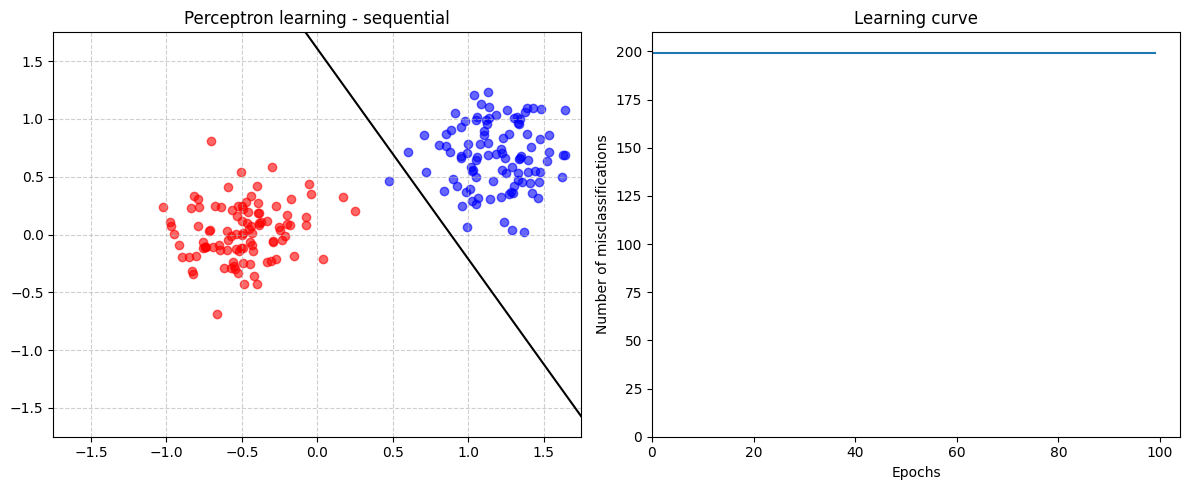

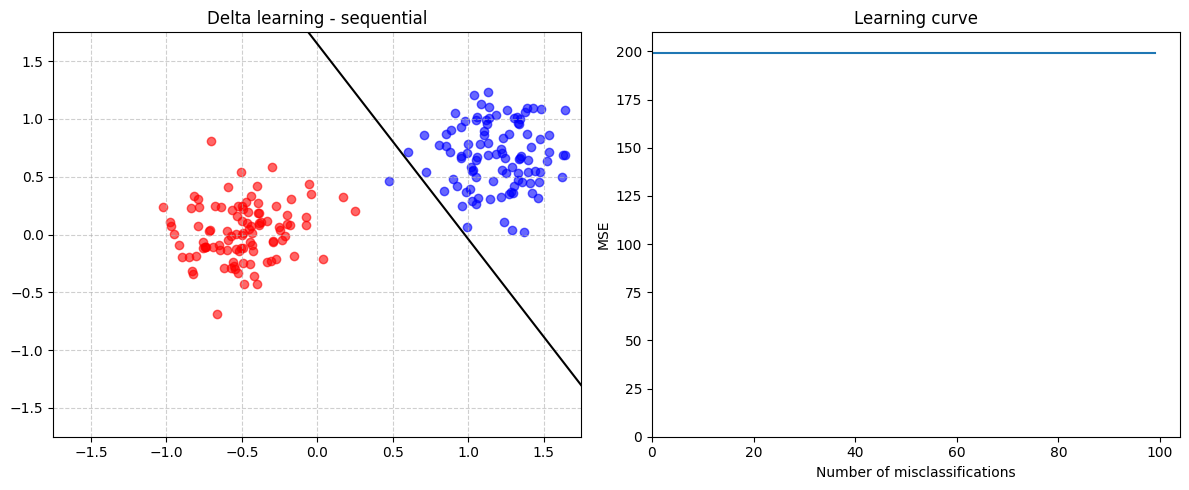

Learning rate: 0.0001


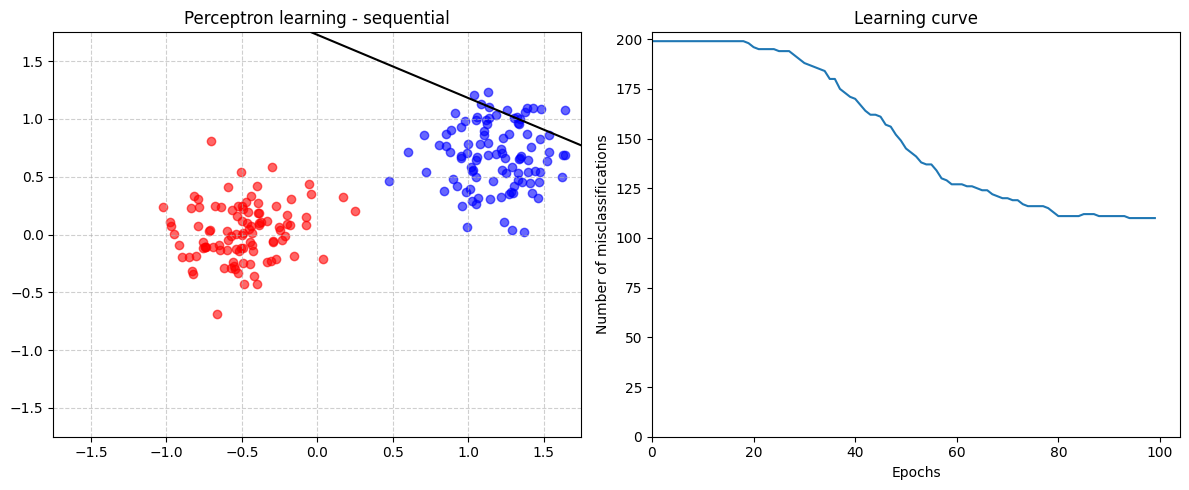

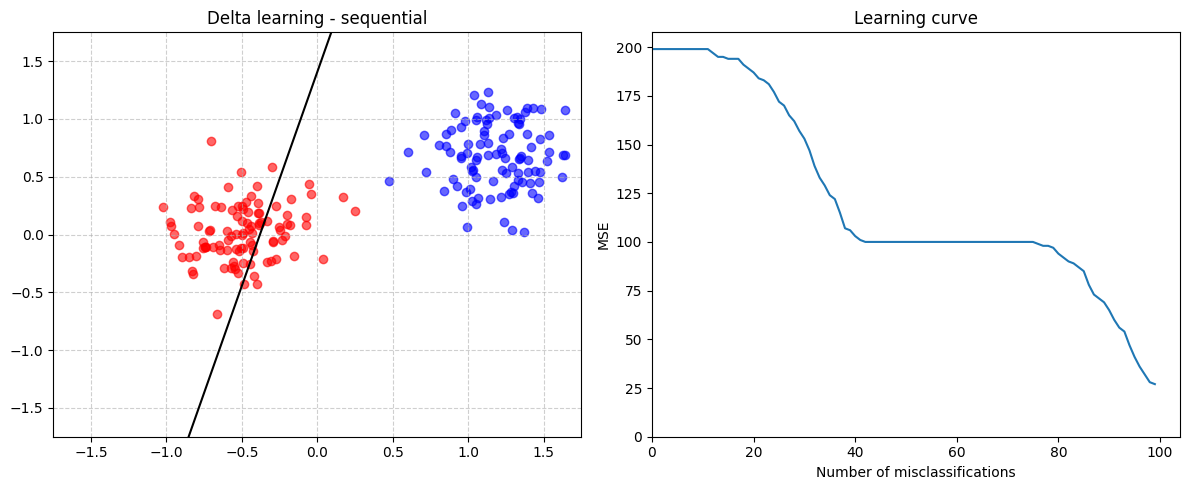

Learning rate: 0.001
Perceptron learning rule (sequential mode) converged at epoch 90!


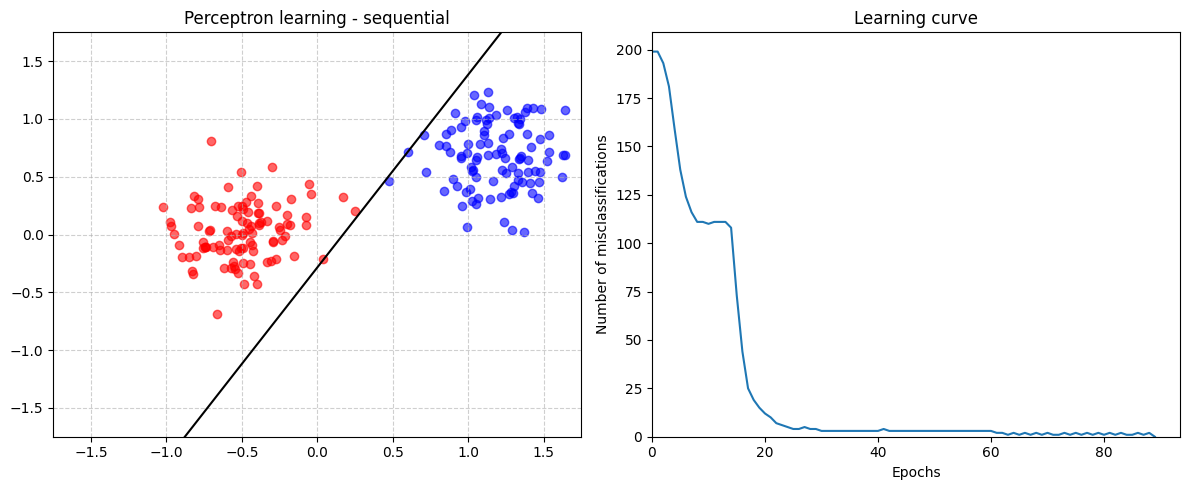

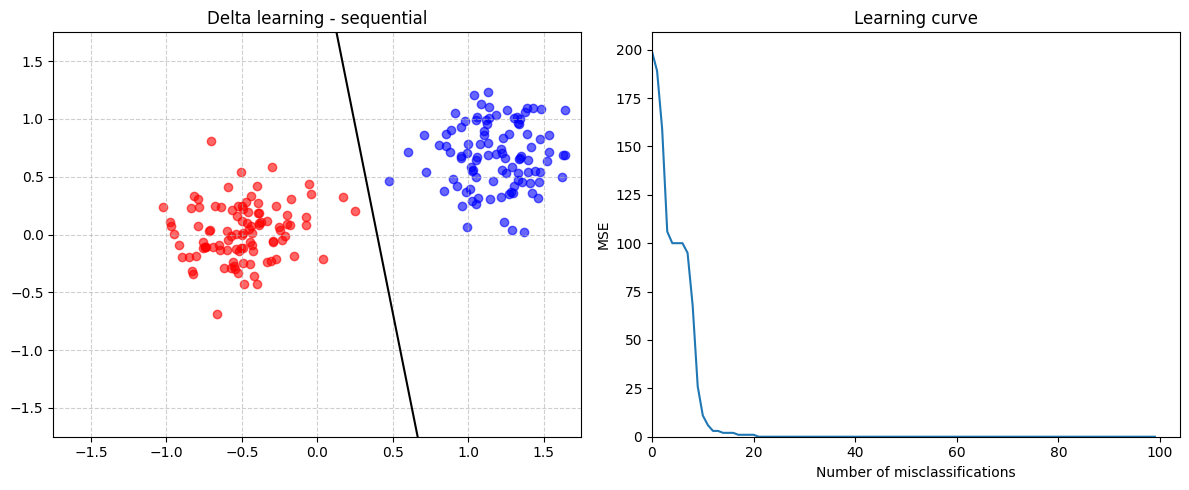

Learning rate: 0.005
Perceptron learning rule (sequential mode) converged at epoch 19!


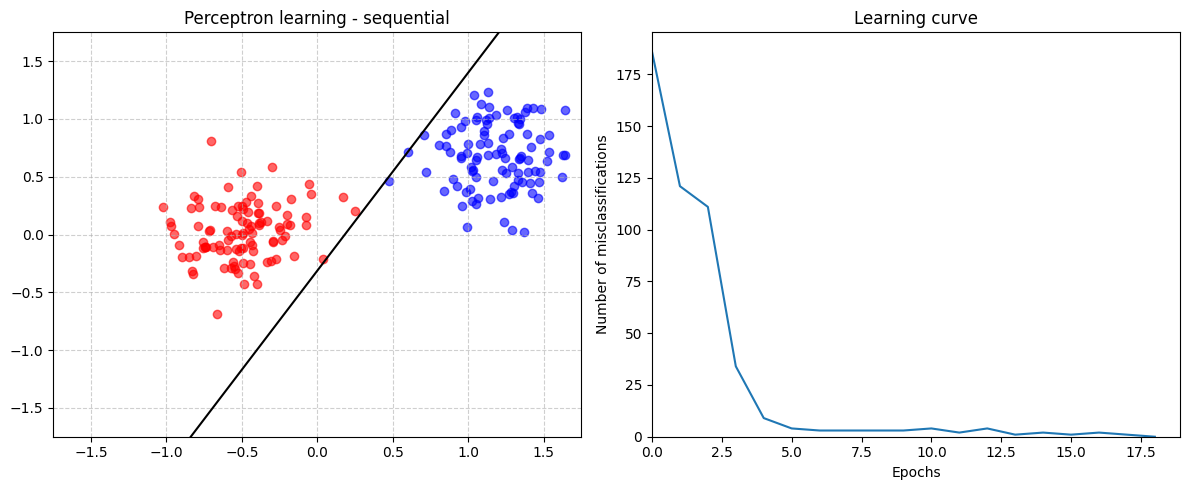

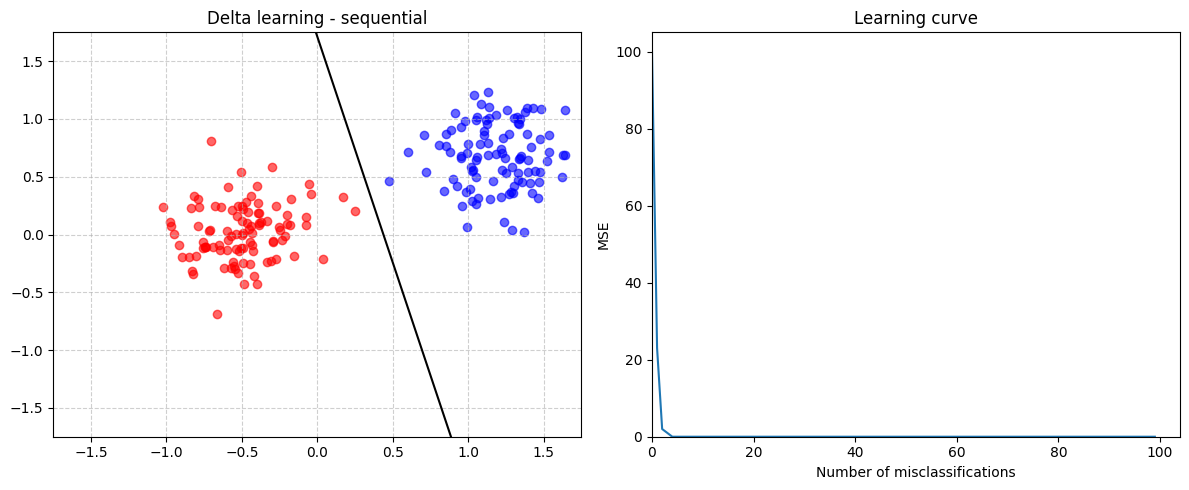

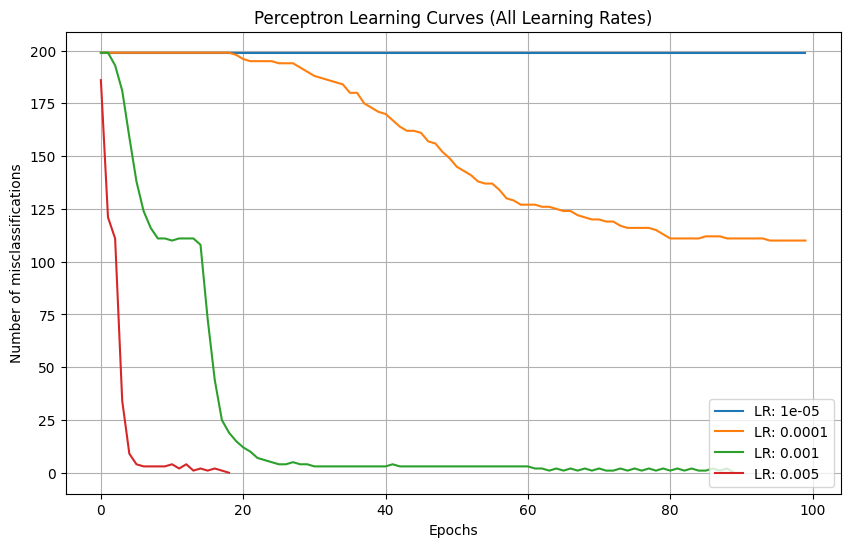

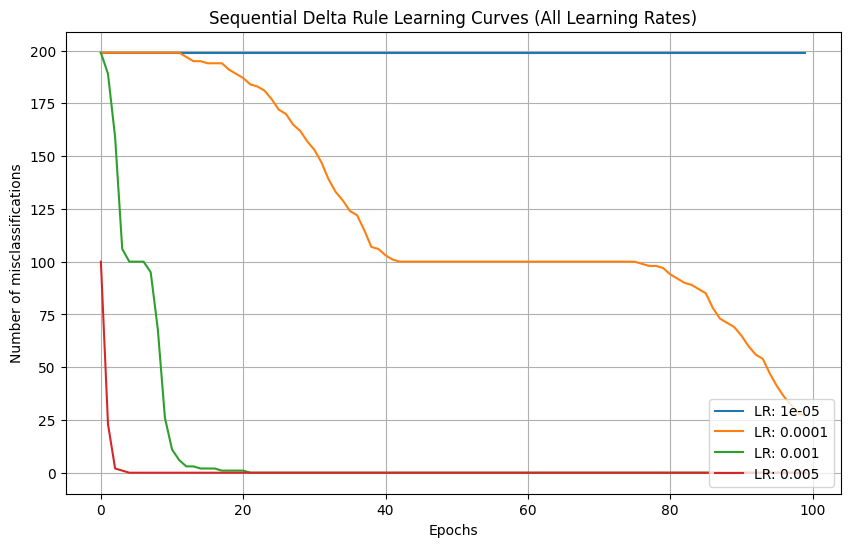

In [10]:
learning_curve_data = {"perceptron":[], "delta": []}

for lr in LRs:
  print(f"Learning rate: {lr}")

  # ======================= PERCEPTRON RULE =====================================
  w_perceptron_online, eh_perceptron_online = perceptron_online(features, labels, weights.copy(), lr=lr, epochs=EPOCHS)

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  learning_curve_data["perceptron"].append(eh_perceptron_online)

  plot_decision_boundary(w_perceptron_online, features, labels, title = "Perceptron learning - sequential", ax=axes[0])
  plot_learning_curve(eh_perceptron_online, xlabel = "Epochs", ylabel = "Number of misclassifications", ax=axes[1])

  plt.tight_layout()
  plt.show()

  # ========================== DELTA RULE ========================================
  w_delta_rule_online, mse, eh_delta_rule_online = delta_rule_online(features, labels, weights.copy(), lr=lr, epochs=EPOCHS)

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  learning_curve_data["delta"].append(eh_delta_rule_online)

  plot_decision_boundary(w_delta_rule_online, features, labels, title = "Delta learning - sequential", ax=axes[0])
  plot_learning_curve(eh_delta_rule_online, xlabel = "Number of misclassifications", ylabel = "MSE", ax=axes[1])

  plt.tight_layout()
  plt.show()

plt.figure(figsize=(10, 6))
for i, lr in enumerate(LRs):
    plt.plot(learning_curve_data["perceptron"][i], label=f"LR: {lr}")

plt.title("Perceptron Learning Curves (All Learning Rates)")
plt.xlabel("Epochs")
plt.ylabel("Number of misclassifications")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for i, lr in enumerate(LRs):
    plt.plot(learning_curve_data["delta"][i], label=f"LR: {lr}")

plt.title("Sequential Delta Rule Learning Curves (All Learning Rates)")
plt.xlabel("Epochs")
plt.ylabel("Number of misclassifications")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### **Comparison of delta learinig algorithm in sequential and batch mode**
- compares delta learning rule / algorithm in two different modes:
  - online / sequential mode
  - batch mode
- learning happens in ```EPOCHS``` many epochs (predefined constant)
- comparison is done over the predefined ```LRs``` constants

Learning rate: 1e-05


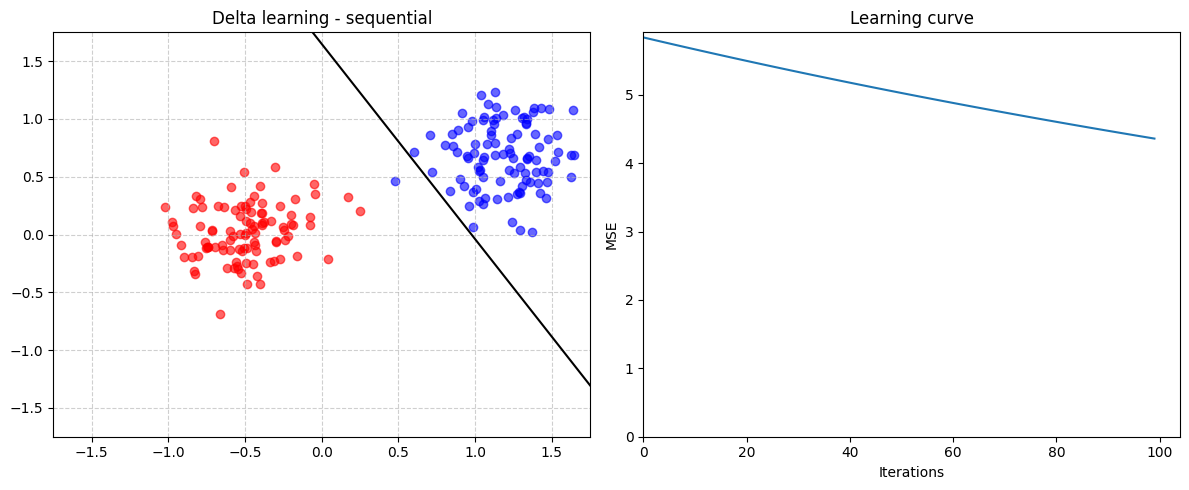

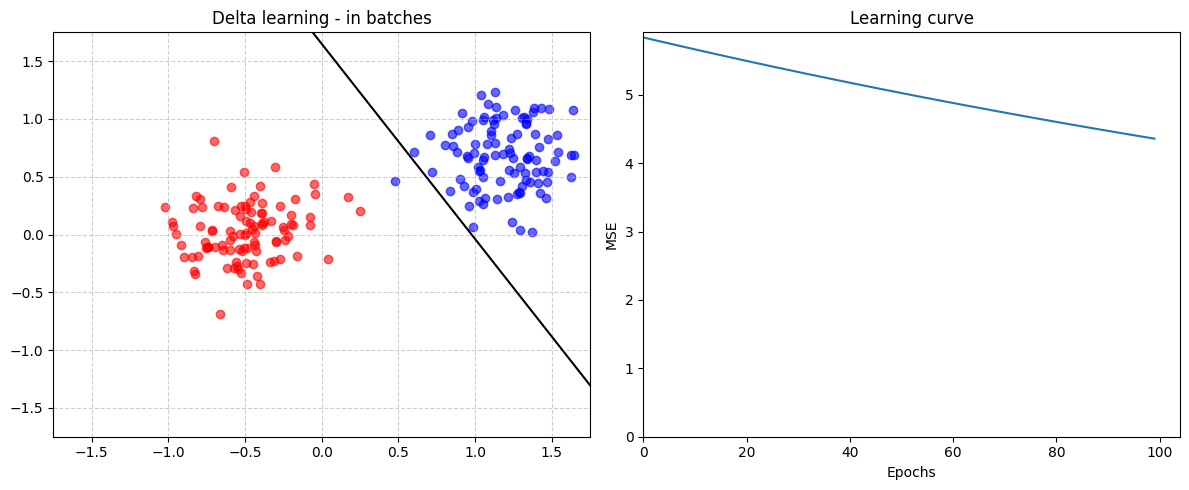

Learning rate: 0.0001


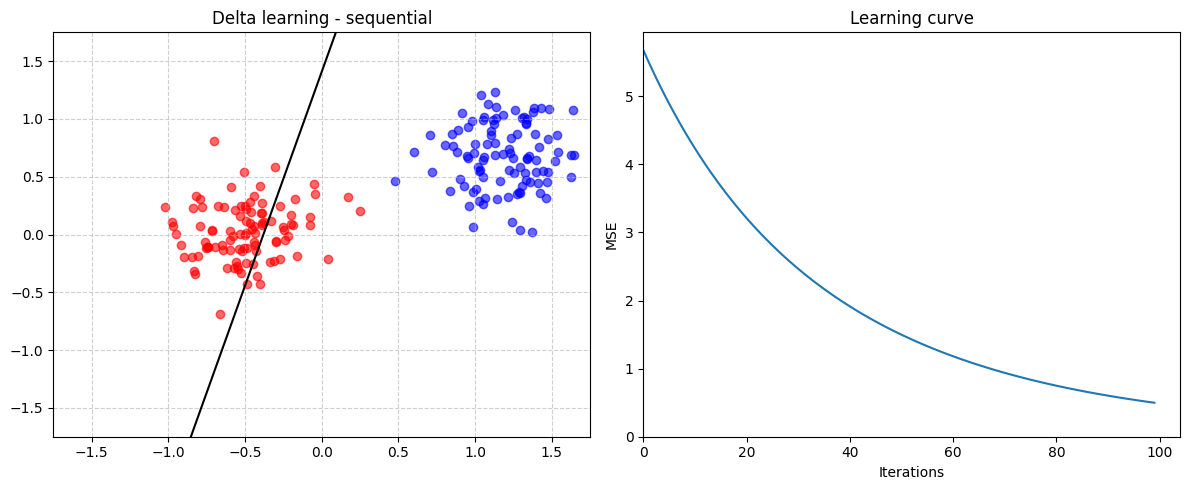

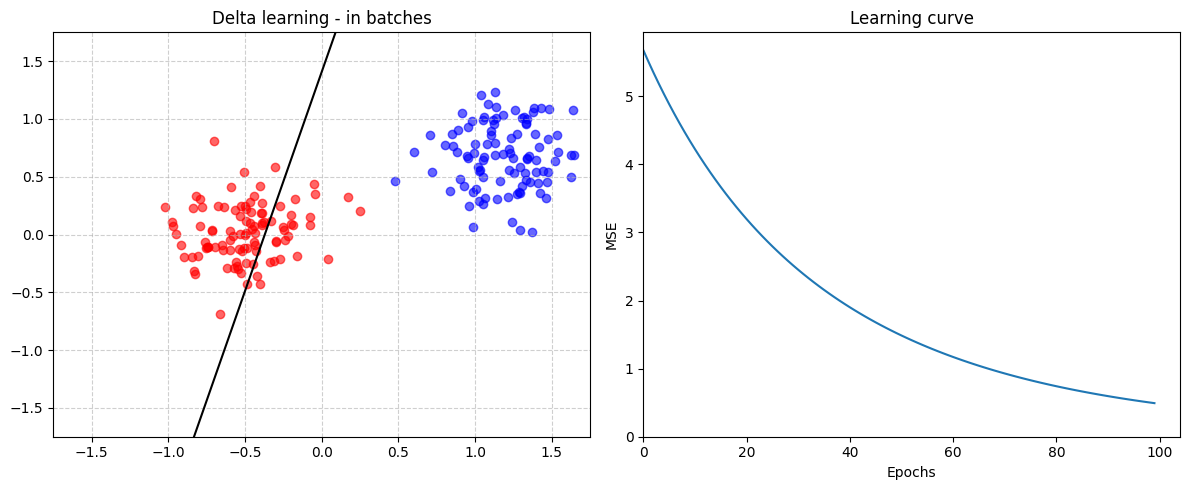

Learning rate: 0.001


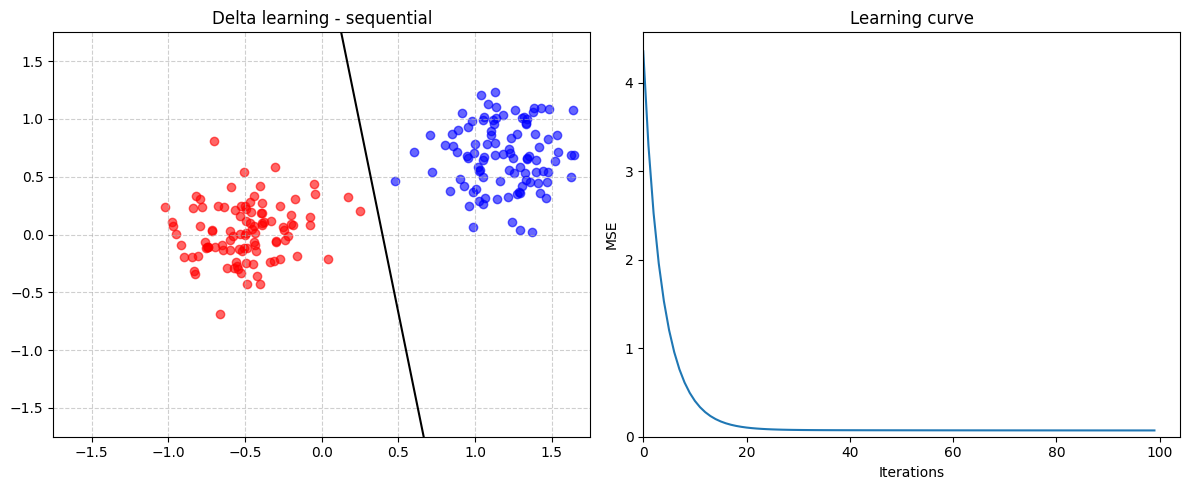

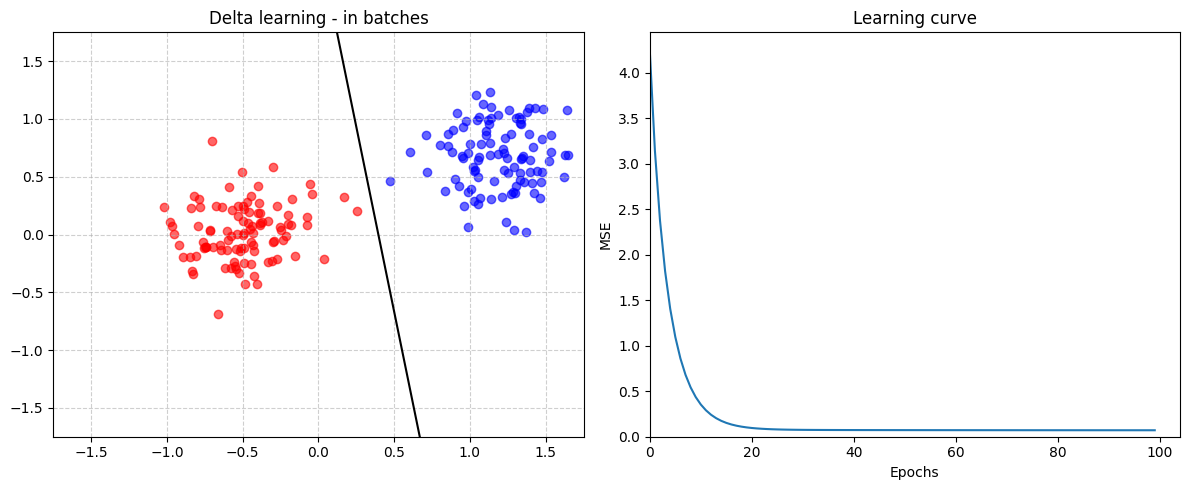

Learning rate: 0.005


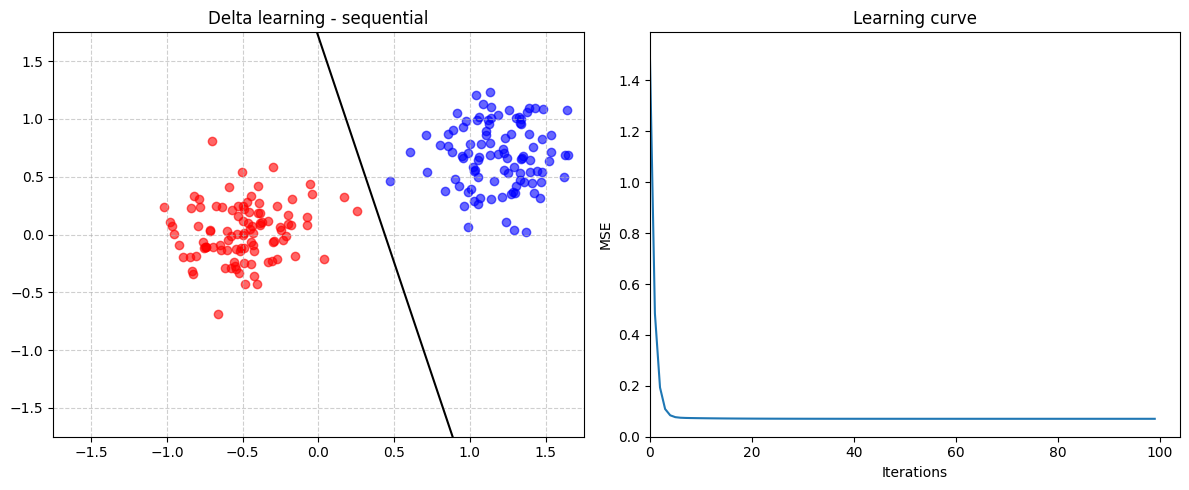

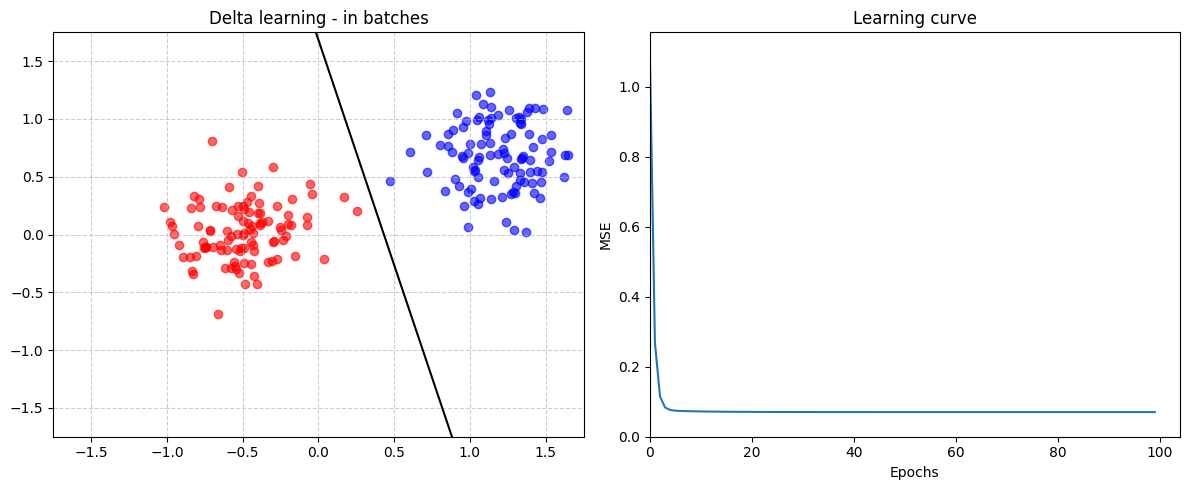

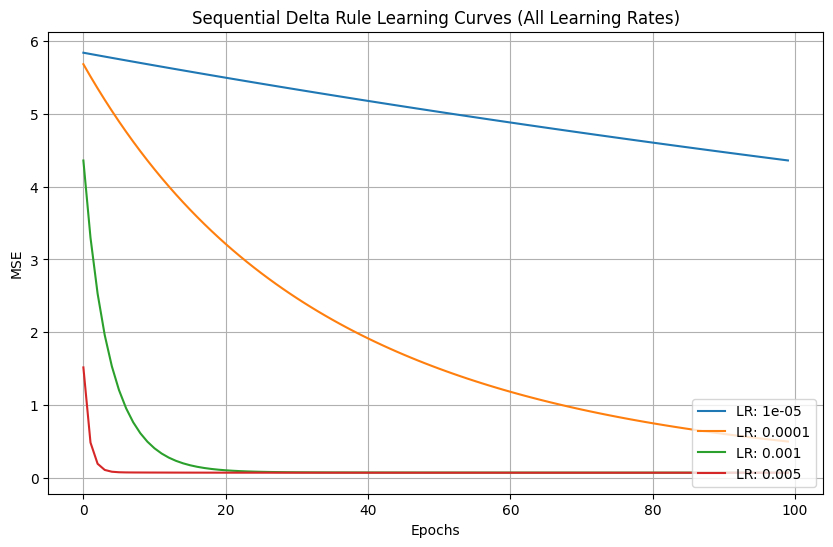

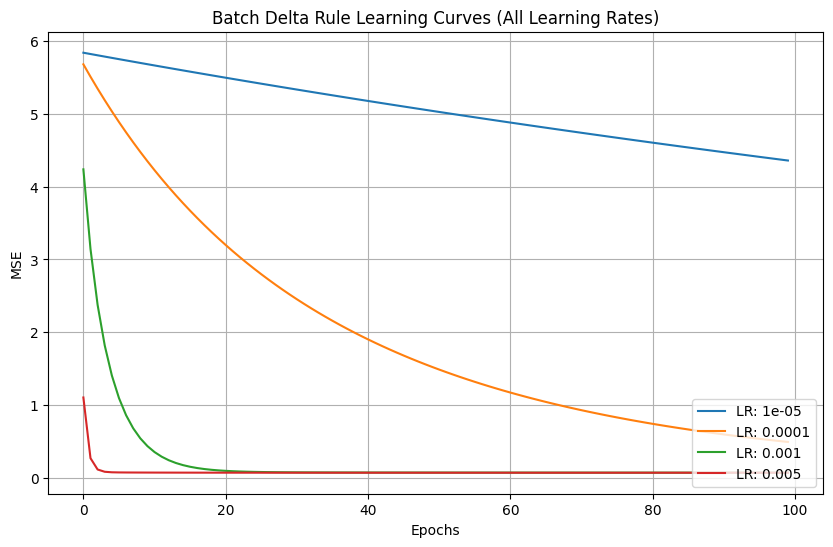

In [11]:
learning_curve_data = {"delta_seq":[], "delta_batch": []}

for lr in LRs:
  print(f"Learning rate: {lr}")

  # ========================== SEQUENTIAL MODE ========================================

  w_delta_rule_online, mse, eh_delta_rule_online = delta_rule_online(features, labels, weights.copy(), lr=lr, epochs=EPOCHS)

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  learning_curve_data["delta_seq"].append(mse)

  plot_decision_boundary(w_delta_rule_online, features, labels, title = "Delta learning - sequential", ax=axes[0])
  plot_learning_curve(mse, xlabel = "Iterations", ylabel = "MSE", ax=axes[1])

  plt.tight_layout()
  plt.show()

  # ============================= BATCH MODE ===========================================

  w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(features, labels, weights.copy(), lr=lr, epochs=EPOCHS)

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  learning_curve_data["delta_batch"].append(error_history)

  plot_decision_boundary(w_delta_rule_batch, features, labels, title = "Delta learning - in batches", ax=axes[0])
  plot_learning_curve(error_history, xlabel = "Epochs", ylabel = "MSE",  ax=axes[1])

  plt.tight_layout()
  plt.show()


plt.figure(figsize=(10, 6))
for i, lr in enumerate(LRs):
    plt.plot(learning_curve_data["delta_seq"][i], label=f"LR: {lr}")

plt.title("Sequential Delta Rule Learning Curves (All Learning Rates)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for i, lr in enumerate(LRs):
    plt.plot(learning_curve_data["delta_batch"][i], label=f"LR: {lr}")

plt.title("Batch Delta Rule Learning Curves (All Learning Rates)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### **Random initialization**

In [12]:
def test_init_sensitivity(features, labels, weights_shape, num_trials=10):
    final_errors = []
    final_misclass = []
    
    for trial in range(num_trials):
        np.random.seed(trial)  
        _, w_init = get_initial_weights(weights_shape, 1)
        
        w_final, misclass_hist, error_hist = delta_rule_batch(
            features, labels, w_init, lr=LR, epochs=N
        )
        
        final_errors.append(error_hist[-1])
        final_misclass.append(misclass_hist[-1])
    
    print(f"Initialization Sensitivity Analysis ({num_trials} trials):")
    print(f"  Final error: mean={np.mean(final_errors):.4f}, std={np.std(final_errors):.4f}")
    print(f"  Final misclass: mean={np.mean(final_misclass):.1f}, std={np.std(final_misclass):.1f}")
    
    return final_errors, final_misclass

In [13]:
def plot_sensitivity(final_errors, final_misclass, num_trials):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Panel 1: Histogram of final errors
    axes[0].hist(final_errors, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(final_errors), color='red', linestyle='--', linewidth=2.5, label='Mean')
    axes[0].axvline(np.median(final_errors), color='orange', linestyle='--', linewidth=2, label='Median')
    axes[0].set_xlabel('Final MSE', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Final Error Distribution\n({num_trials} trials)', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].hist(final_misclass, bins=20, color='coral', alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(final_misclass), color='red', linestyle='--', linewidth=2.5, label='Mean')
    axes[1].axvline(np.median(final_misclass), color='orange', linestyle='--', linewidth=2, label='Median')
    axes[1].set_xlabel('Misclassifications', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[1].set_title(f'Final Misclass Distribution\n({num_trials} trials)', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

Initialization Sensitivity Analysis (10000 trials):
  Final error: mean=0.0756, std=0.0075
  Final misclass: mean=0.0, std=0.0


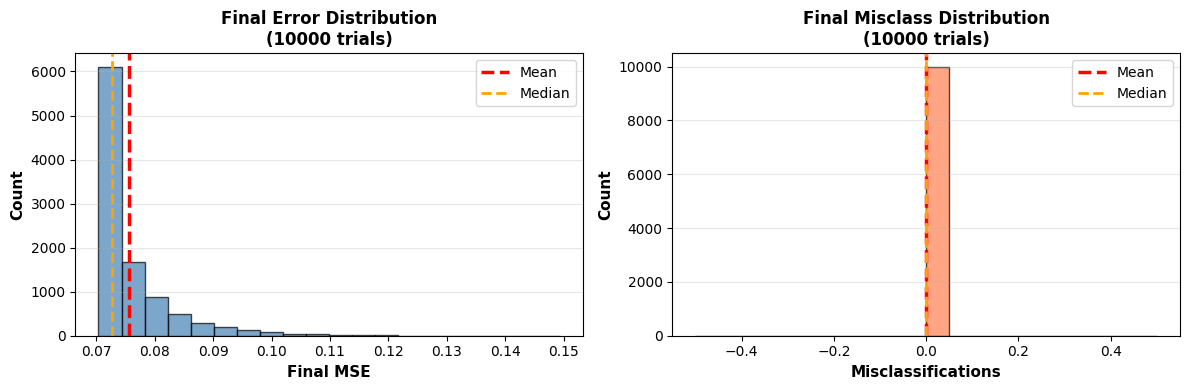

In [14]:
errors, misclass = test_init_sensitivity(features, labels, (1, 2), num_trials=N*N)
plot_sensitivity(errors, misclass, N*N)

#### **Delta learinig algorithm in batch mode with no bias**
- tests delta rule in batch mode when no bias is added in weights

Learning rate: 1e-05


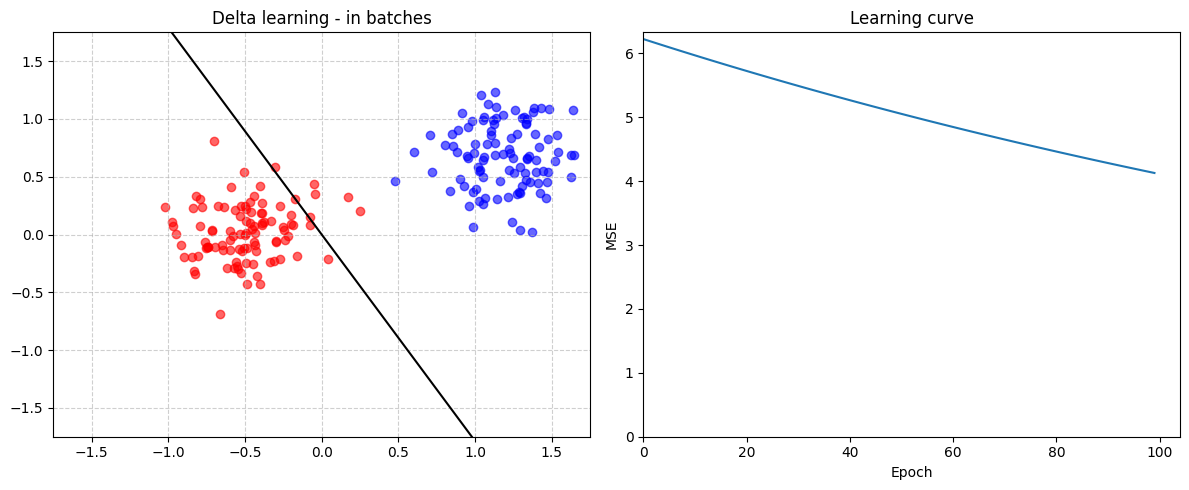

Learning rate: 0.0001


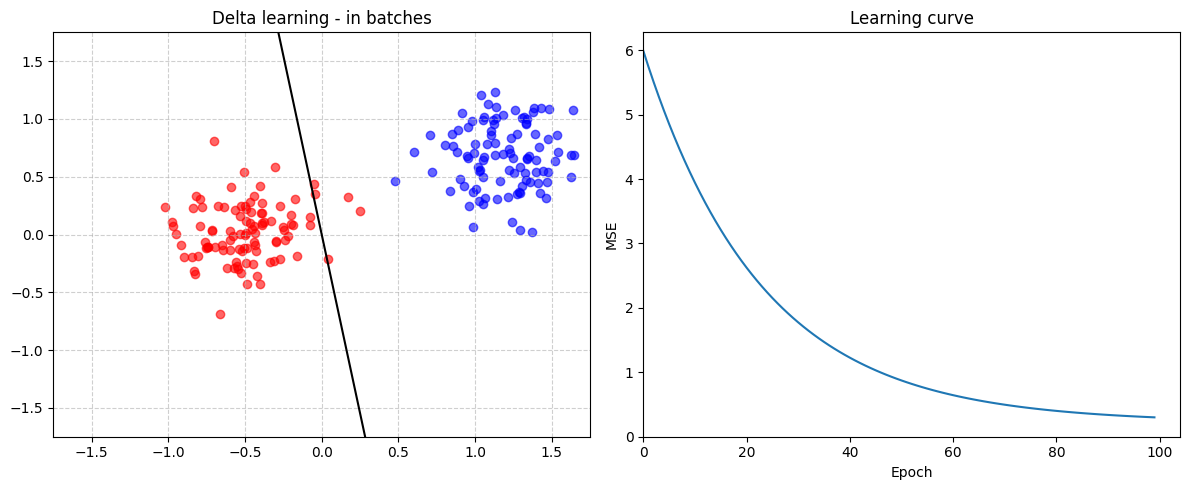

Learning rate: 0.001


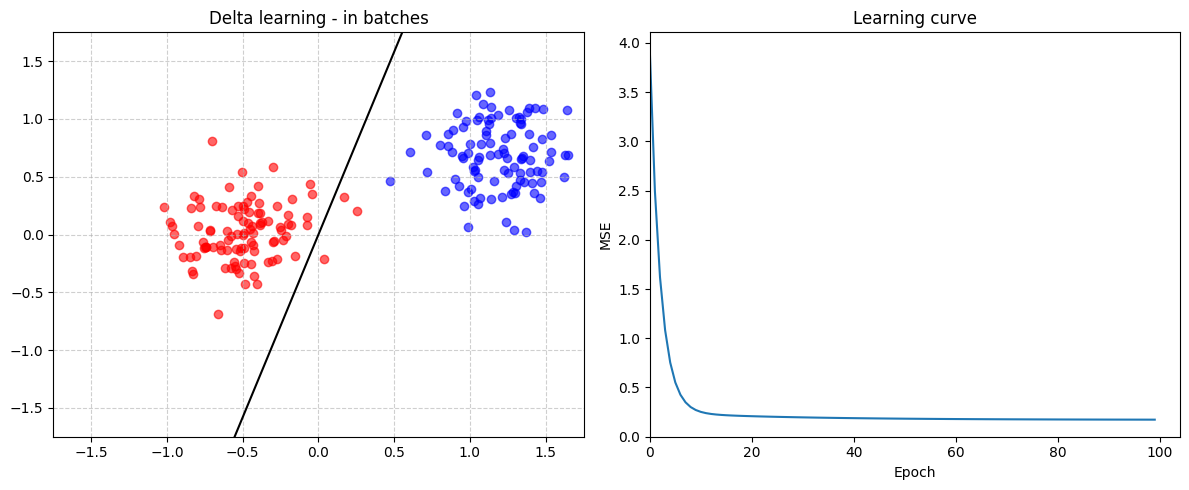

Learning rate: 0.005


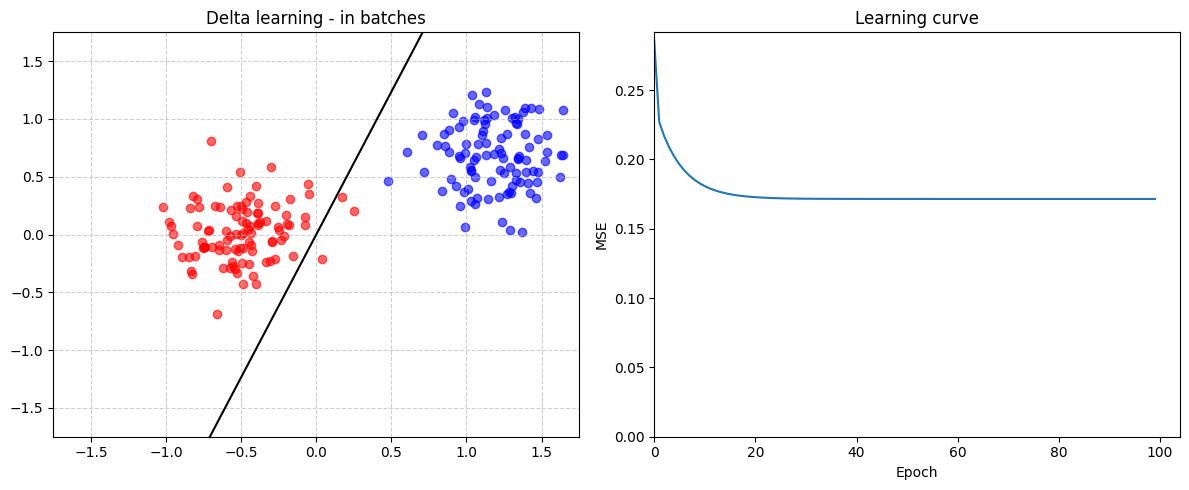

In [15]:
for lr in LRs:
  print(f"Learning rate: {lr}")

  # ============================= BATCH MODE ===========================================

  w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
      features_without_bias, labels, weights_without_bias.copy(), lr=lr, epochs=EPOCHS
    )

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  plot_decision_boundary(
      w_delta_rule_batch, features_without_bias, labels, title = "Delta learning - in batches", ax=axes[0], bias=False
  )
  plot_learning_curve(error_history, xlabel = "Epoch", ylabel = "MSE",  ax=axes[1])

  plt.tight_layout()
  plt.show()

- generating new linearly separable data with new ```mA``` and ```mB``` parameters
- testing delta rule in batch mode with the same initial wights **without** bias term

Learning rate: 1e-05


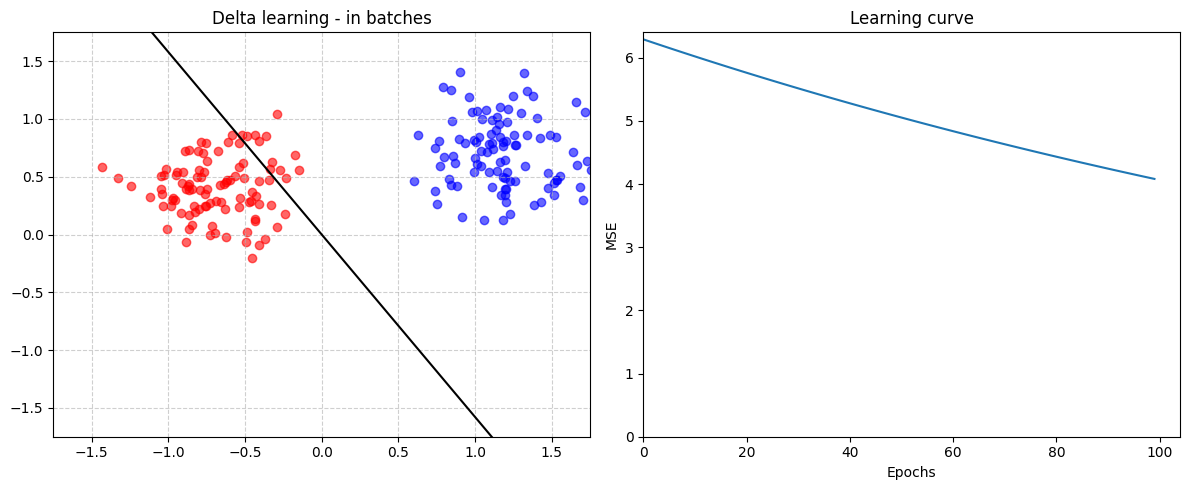

Learning rate: 0.0001


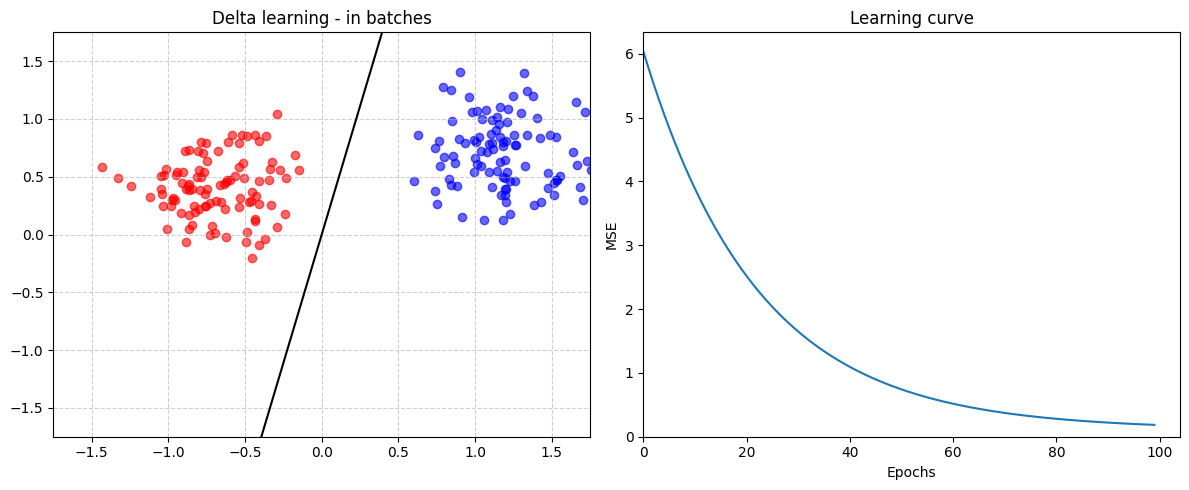

Learning rate: 0.001


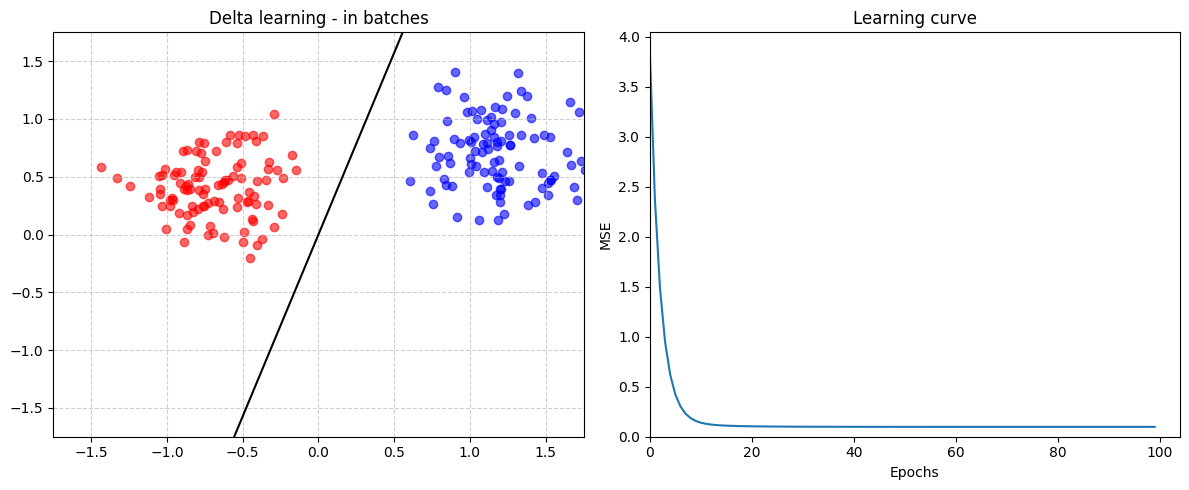

Learning rate: 0.005


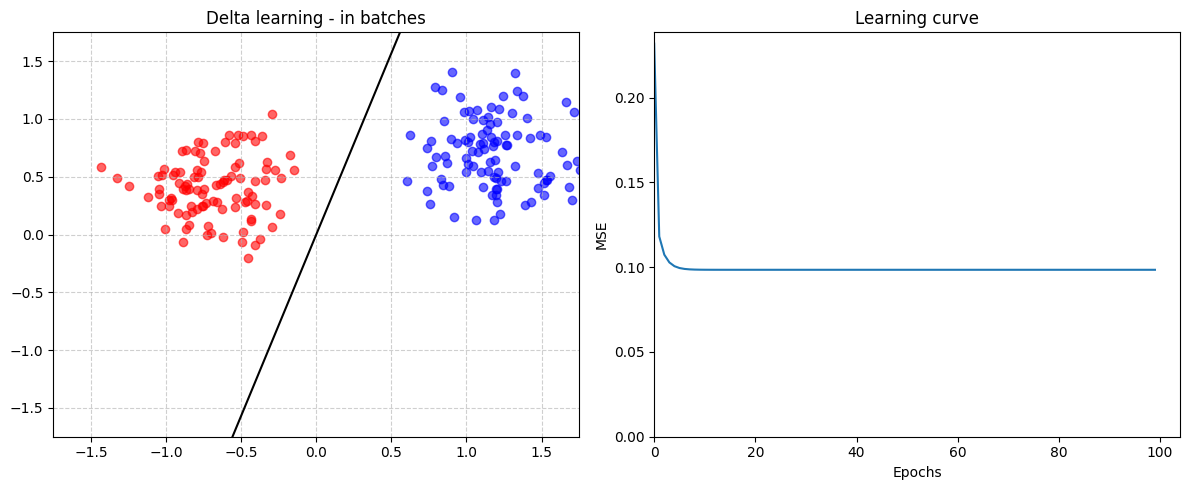

In [16]:
mA = np.array([ 1.2, 0.7]) # mean of cluster A
sigmaA = 0.25

mB = np.array([-0.7, 0.4]) # mean of cluster B
sigmaB = 0.25

_, features_without_bias2, labels2 = generate_data_clouds(N, mA, mB, sigmaA, sigmaB)

for lr in LRs:
  print(f"Learning rate: {lr}")

  # ============================= BATCH MODE ===========================================

  w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
      features_without_bias2, labels2, weights_without_bias.copy(), lr=lr, epochs=EPOCHS
    )

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  plot_decision_boundary(
      w_delta_rule_batch, features_without_bias2, labels2, title = "Delta learning - in batches", ax=axes[0], bias=False
  )
  plot_learning_curve(error_history, xlabel = "Epochs", ylabel = "MSE",  ax=axes[1])

  plt.tight_layout()
  plt.show()

## **3.1.3 Classification of samples that are not linearly separable**

### Training on lineary insaperable data clouds

#### Generating lineary insaperable data clouds

In [17]:
mA = np.array([ 0.65, 0.7]) # mean of cluster A
sigmaA = 0.35

mB = np.array([-0.65, 0.4]) # mean of cluster B
sigmaB = 0.35

features3, _, labels3 = generate_data_clouds(N, mA, mB, sigmaA, sigmaB)

#### Perceptrone learning rule - sequential

Learning rate: 1e-05


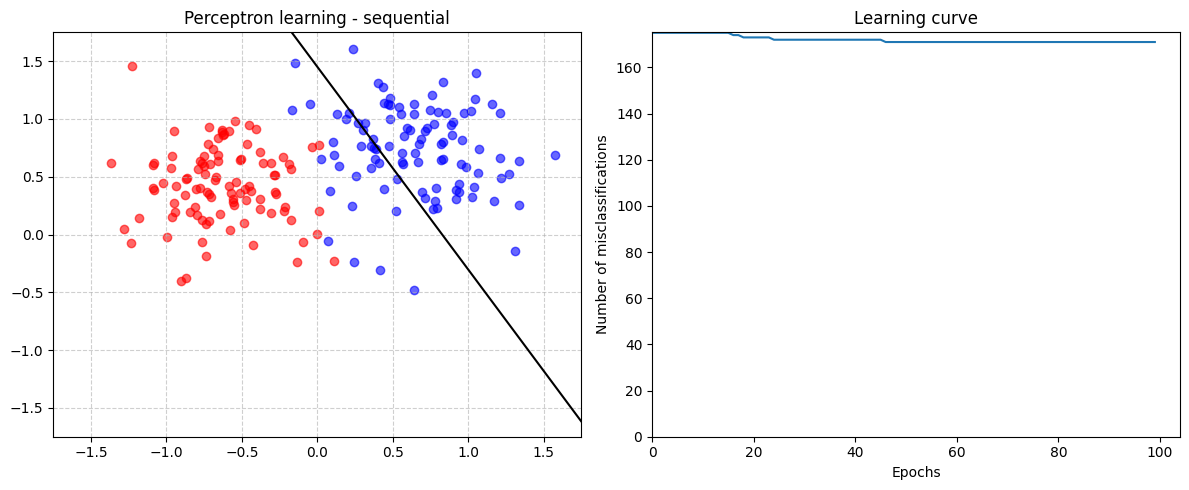

Learning rate: 0.0001


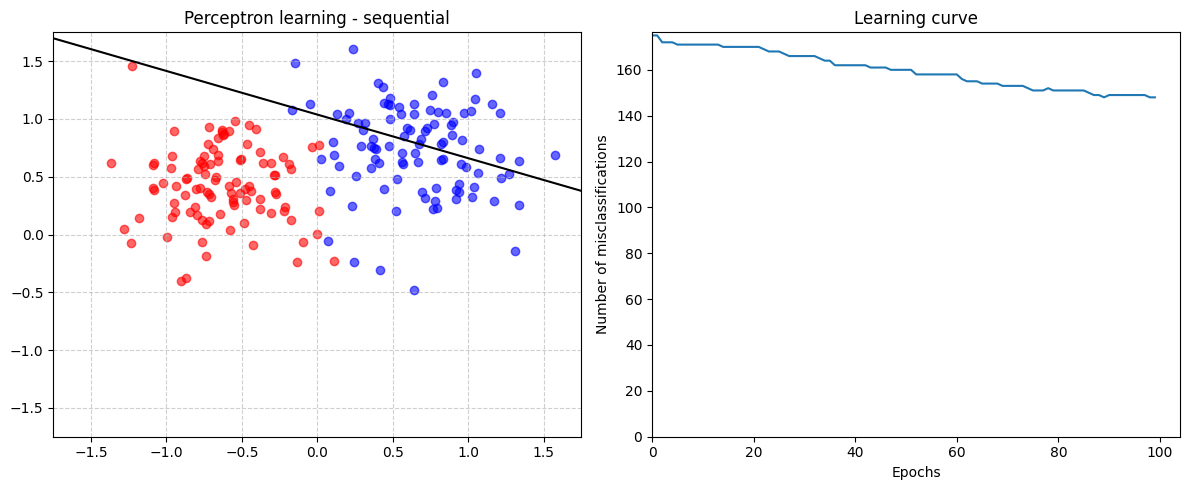

Learning rate: 0.001


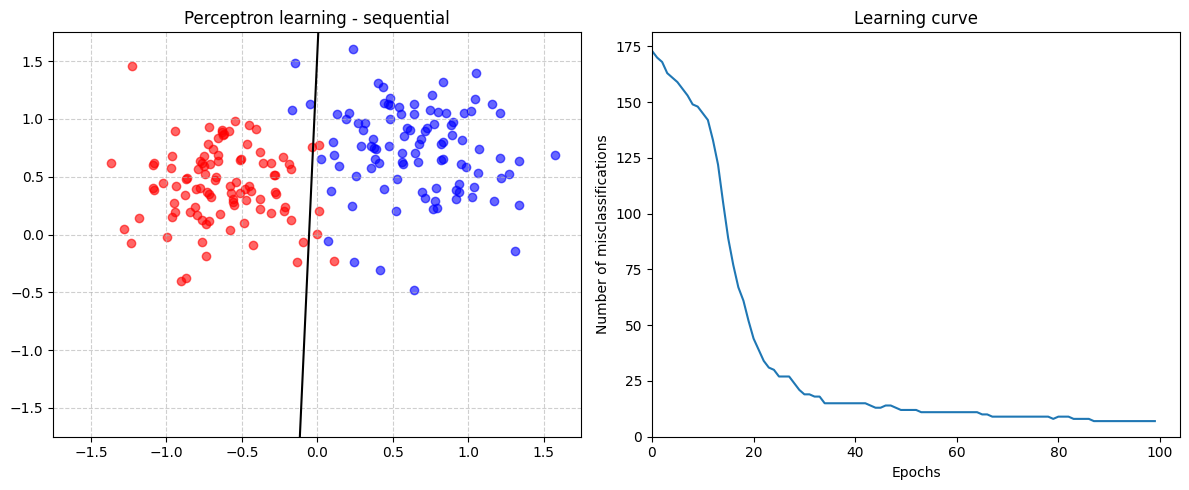

Learning rate: 0.005


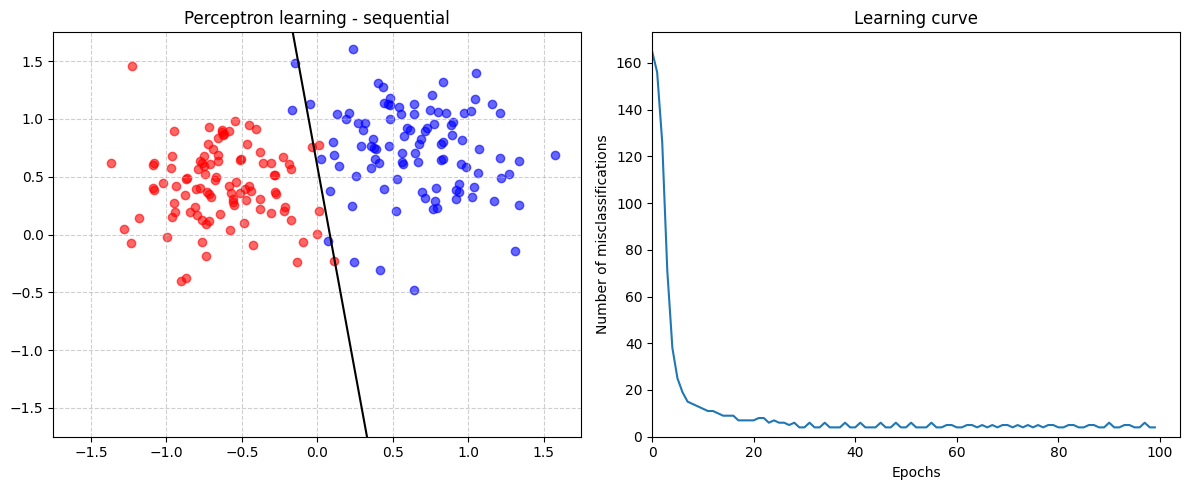

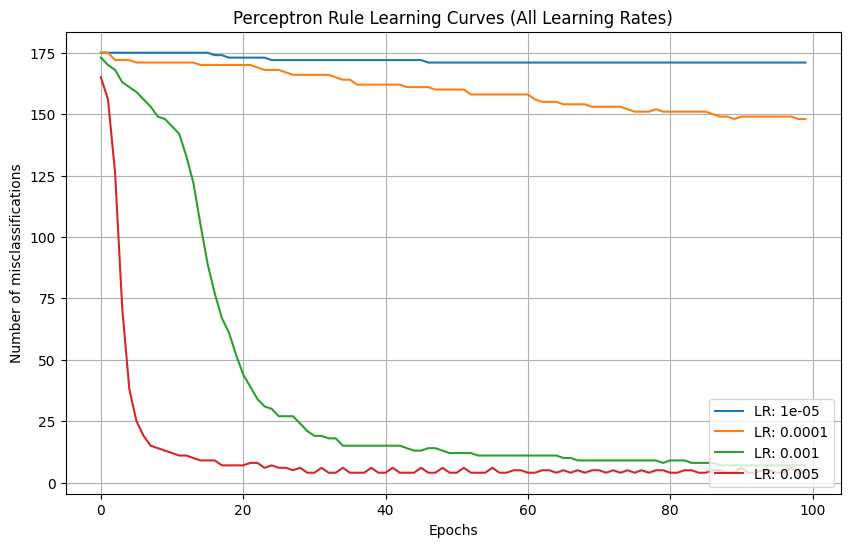

In [18]:
errors = []

for lr in LRs:
    print(f"Learning rate: {lr}")

    w_perceptron_online, eh_perceptron_online = perceptron_online(
        features3, labels3, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    errors.append(eh_perceptron_online)

    plot_decision_boundary(
        w_perceptron_online, features3, labels3, title = "Perceptron learning - sequential", ax=axes[0]
    )
    plot_learning_curve(eh_perceptron_online, xlabel = "Epochs", ylabel = "Number of misclassifications", ax=axes[1])

    plt.tight_layout()
    plt.show()


plt.figure(figsize=(10, 6))
for i, lr in enumerate(LRs):
    plt.plot(errors[i], label=f"LR: {lr}")

plt.title("Perceptron Rule Learning Curves (All Learning Rates)")
plt.xlabel("Epochs")
plt.ylabel("Number of misclassifications")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Delta learning rule - sequential

Learning rate: 1e-05


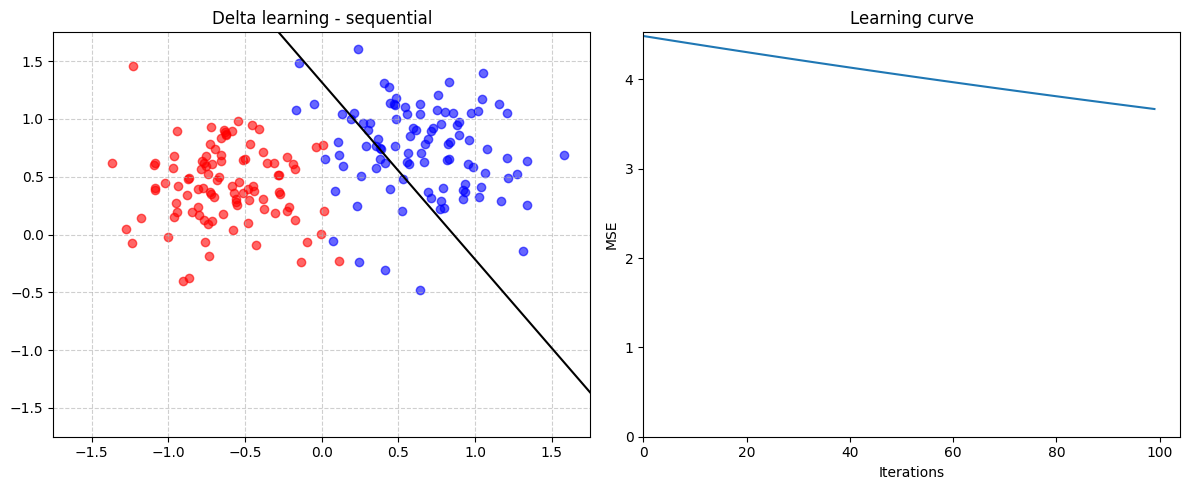

Learning rate: 0.0001


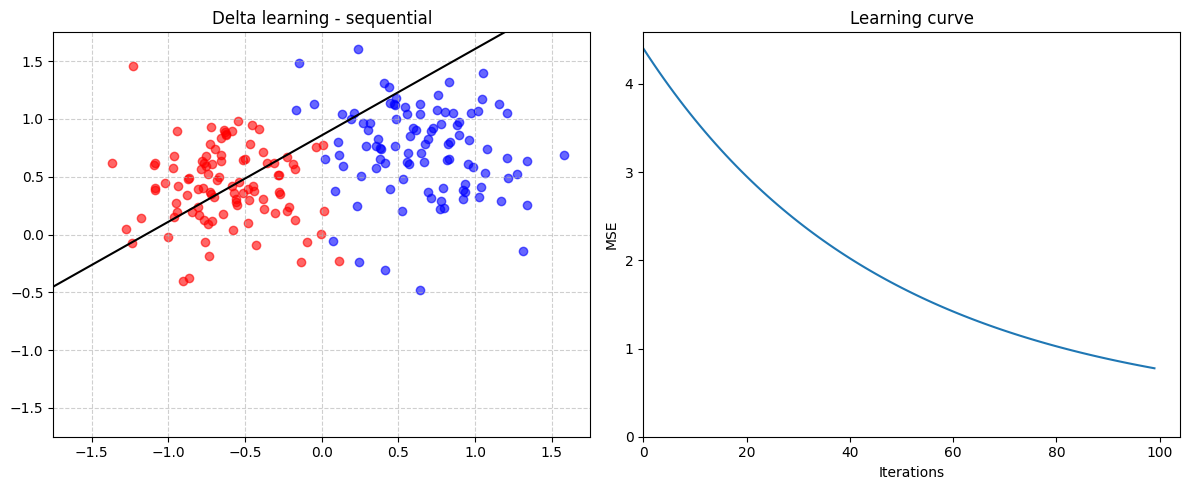

Learning rate: 0.001


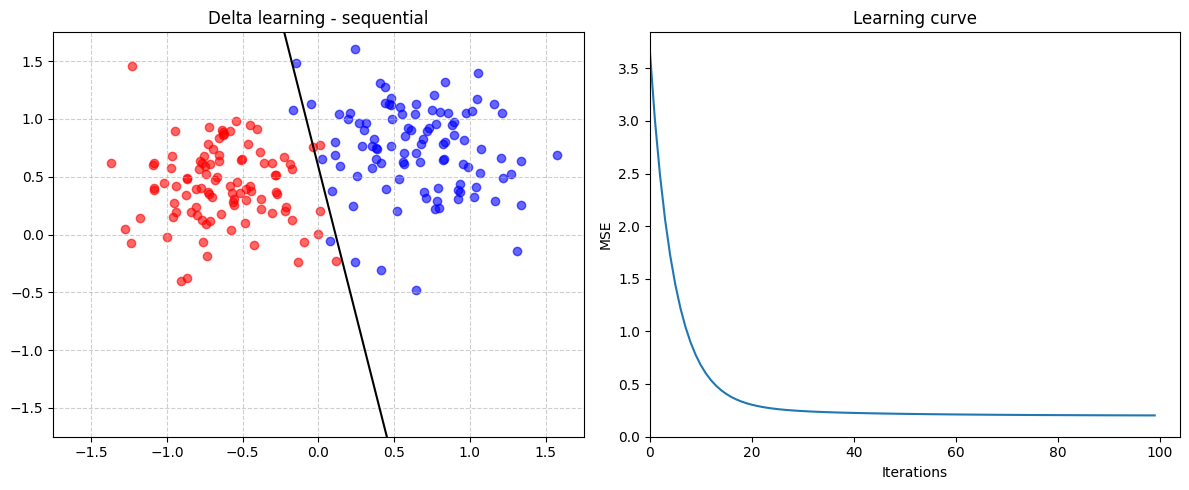

Learning rate: 0.005


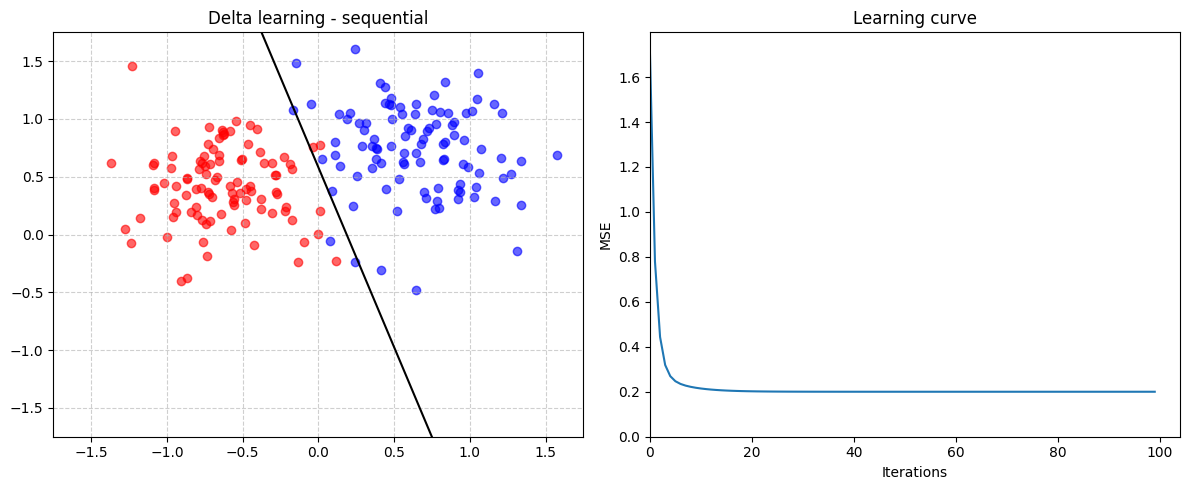

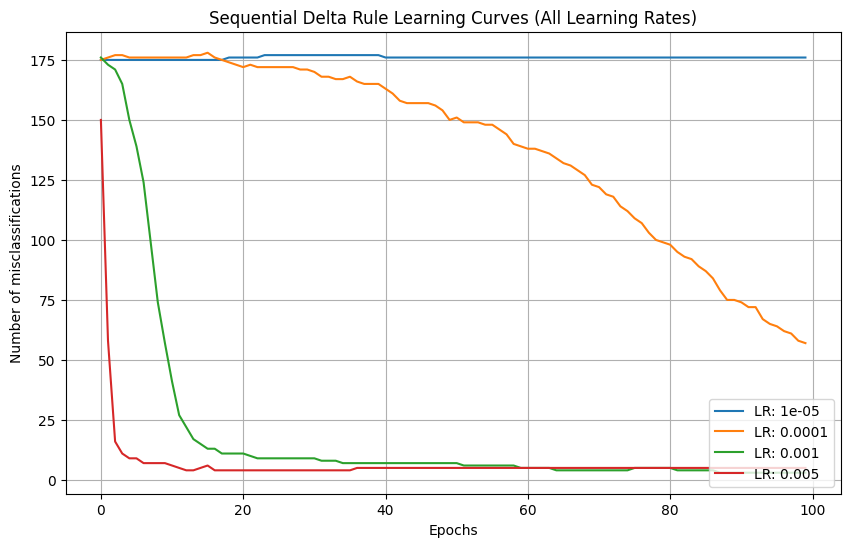

In [19]:
errors = []

for lr in LRs:
    print(f"Learning rate: {lr}")

    w_delta_rule_online, mse, eh_delta_rule_online = delta_rule_online(
        features3, labels3, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    errors.append(eh_delta_rule_online)

    plot_decision_boundary(w_delta_rule_online, features3, labels3, title = "Delta learning - sequential", ax=axes[0])
    plot_learning_curve(mse, xlabel = "Iterations", ylabel = "MSE", ax=axes[1])

    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 6))
for i, lr in enumerate(LRs):
    plt.plot(errors[i], label=f"LR: {lr}")

plt.title("Sequential Delta Rule Learning Curves (All Learning Rates)")
plt.xlabel("Epochs")
plt.ylabel("Number of misclassifications")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Delta learning rule - batch

Learning rate: 1e-05


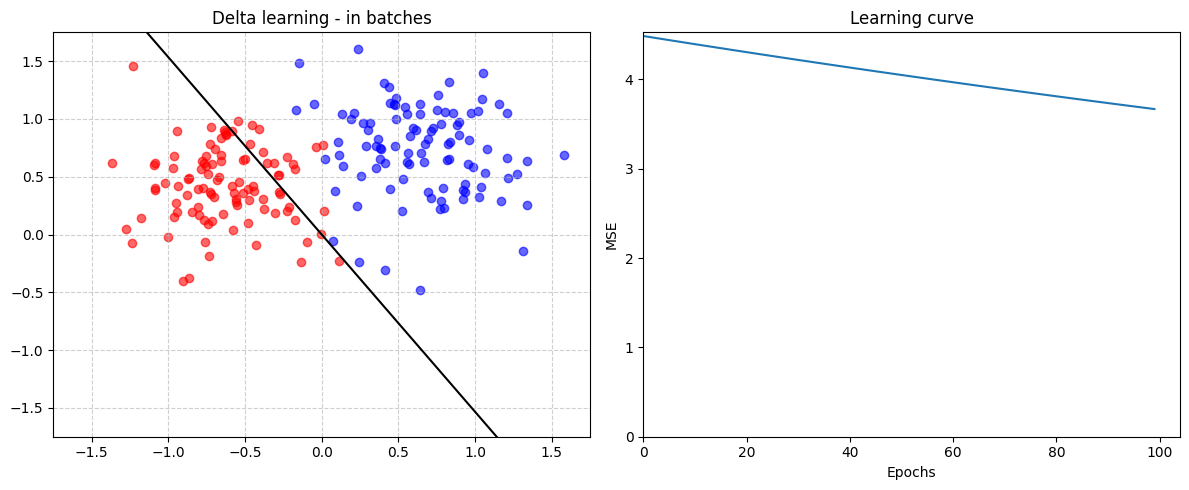

Learning rate: 0.0001


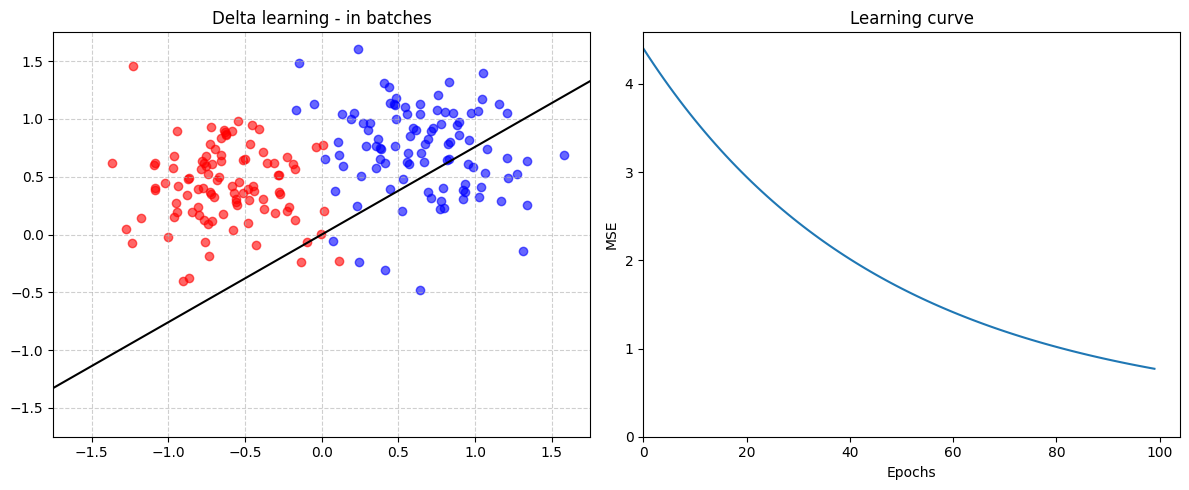

Learning rate: 0.001


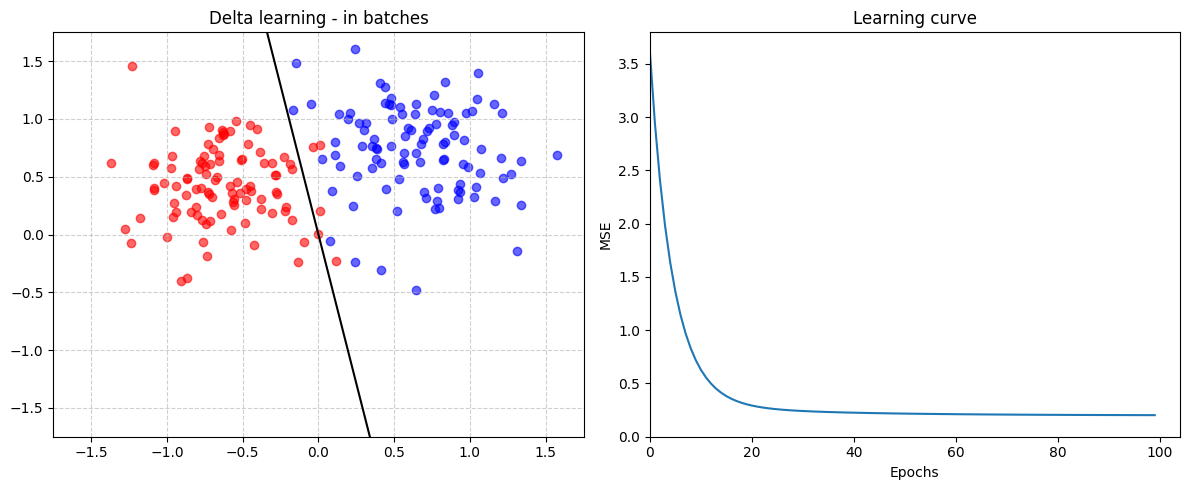

Learning rate: 0.005


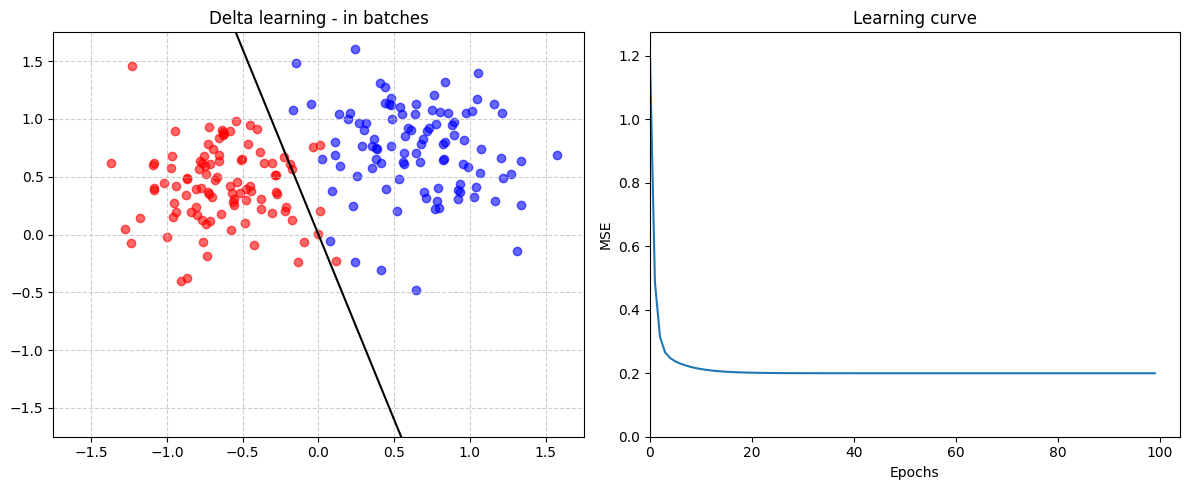

In [20]:
for lr in LRs:
    print(f"Learning rate: {lr}")
    
    w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
     features3, labels3, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_delta_rule_batch, features3, labels3, title = "Delta learning - in batches", ax=axes[0], bias=False
    )
    plot_learning_curve(error_history, xlabel = "Epochs", ylabel = "MSE",  ax=axes[1])

    plt.tight_layout()
    plt.show()

### Training on lineary insaperable data - new dataset
- ```classA``` has two clouds of 50 points each concentrated around different points (means of normal distribution)
- ```classB``` is still one cloud of 100 points

#### Generating new lineary insaperable dataset
- generating new dataset
- shuffling the new dataset

In [21]:
h = N // 2

mA = np.array([ 1.0, 0.3])
sigmaA = 0.2
classA = np.zeros((2, N))

# classA: x-coordinates (horizontal space between clouds)
classA[0, :] = np.concatenate([
    np.random.randn(h) * sigmaA - mA[0],
    np.random.randn(h) * sigmaA + mA[0]
])

# classA: y-coordinates 
classA[1, :] = np.random.randn(N) * sigmaA + mA[1]

mB = np.array([0.0, -0.1])
sigmaB = 0.3
classB = np.zeros((2, N))

# classB: x- and y-coordinates
classB[0, :] = np.random.randn(N) * sigmaB + mB[0]
classB[1, :] = np.random.randn(N) * sigmaB + mB[1]

features = np.hstack([classA, classB])
labels = np.hstack([np.ones(N), -np.ones(N)])

# shuffling
random_indexes = np.random.permutation(N*2) 
features, labels = features[:, random_indexes], labels[random_indexes]

features_without_bias = np.array(features)
bias_row = np.ones((1, features.shape[1]))

features = np.vstack([features_without_bias, bias_row])

print("feature matrix: ", features.shape)
print("feature matrix without bias: ", features_without_bias.shape)
print("labels matrix: ", labels.shape)
print("weights matrix: ", weights.shape)
print("weights matrix without bias: ", weights_without_bias.shape)

feature matrix:  (3, 200)
feature matrix without bias:  (2, 200)
labels matrix:  (200,)
weights matrix:  (1, 3)
weights matrix without bias:  (1, 2)


In [22]:
def compute_per_class_accuracy(weights, features, labels):
    """
    Computes accuracy separately for class A (label = 1) and class B (label = -1),
    plus the overall accuracy.
 
    Args:
        weights (np.ndarray): shape (1, D) trained weight vector (bias included
            as the last column if `features` has a bias row).
        features (np.ndarray): shape (D, n_samples) feature matrix, bias row
            included if the weights expect one.
        labels (np.ndarray): shape (n_samples,) true labels (+1 / -1).
 
    Returns:
        dict with keys 'acc_A', 'acc_B', 'acc_overall', 'n_A', 'n_B'.
        Class accuracies are np.nan if that class has zero samples in `labels`
        (e.g. the "removed" set for a scenario that didn't touch that class).
    """
    predictions = np.sign(weights @ features).flatten()
    # np.sign can return 0 for an exact zero output; treat 0 as a misclassification
    # for the -1 class and correct for neither, so nudge zeros to -1 explicitly.
    predictions[predictions == 0] = -1
 
    mask_A = labels == 1
    mask_B = labels == -1
 
    acc_A = np.mean(predictions[mask_A] == labels[mask_A]) if mask_A.sum() > 0 else np.nan
    acc_B = np.mean(predictions[mask_B] == labels[mask_B]) if mask_B.sum() > 0 else np.nan
    acc_overall = np.mean(predictions == labels) if labels.size > 0 else np.nan
 
    return {
        "acc_A": acc_A,
        "acc_B": acc_B,
        "acc_overall": acc_overall,
        "n_A": int(mask_A.sum()),
        "n_B": int(mask_B.sum()),
    }
 
 
# ---------------------------------------------------------------------------
# 2. Helper to build feature/label matrices (with bias row) from raw clouds
# ---------------------------------------------------------------------------
 
def build_features_labels(A_points, B_points):
    """
    Stacks classA/classB point clouds into a single bias-augmented feature
    matrix and a matching label vector. Handles the case where one of the
    clouds is empty (0 columns), which happens e.g. for the "removed" set
    when a scenario doesn't remove anything from that class.
 
    Args:
        A_points (np.ndarray): shape (2, n_A), possibly n_A == 0.
        B_points (np.ndarray): shape (2, n_B), possibly n_B == 0.
 
    Returns:
        features (np.ndarray): shape (3, n_A + n_B) with bias row appended.
        labels (np.ndarray): shape (n_A + n_B,), +1 for A, -1 for B.
    """
    n_A = A_points.shape[1]
    n_B = B_points.shape[1]
 
    if n_A == 0 and n_B == 0:
        return np.zeros((3, 0)), np.zeros((0,))
 
    points = np.hstack([A_points, B_points]) if n_A > 0 and n_B > 0 else (
        A_points if n_B == 0 else B_points
    )
    labels = np.hstack([np.ones(n_A), -np.ones(n_B)])
    bias_row = np.ones((1, points.shape[1]))
    features = np.vstack([points, bias_row])
    return features, labels
 
 
# ---------------------------------------------------------------------------
# 3. Scenario functions: return (keepA, removeA, keepB, removeB) index arrays
# ---------------------------------------------------------------------------
 
def scenario_random25(classA, classB, rng):
    """Type I: remove a random 25% from EACH class independently."""
    nA, nB = classA.shape[1], classB.shape[1]
    n_remove_A = int(0.25 * nA)
    n_remove_B = int(0.25 * nB)
 
    removeA = rng.choice(nA, size=n_remove_A, replace=False)
    removeB = rng.choice(nB, size=n_remove_B, replace=False)
    keepA = np.setdiff1d(np.arange(nA), removeA)
    keepB = np.setdiff1d(np.arange(nB), removeB)
    return keepA, removeA, keepB, removeB
 
 
def scenario_half_A(classA, classB, rng):
    """Type II: remove a random 50% from classA only; classB untouched."""
    nA, nB = classA.shape[1], classB.shape[1]
    n_remove_A = int(0.5 * nA)
 
    removeA = rng.choice(nA, size=n_remove_A, replace=False)
    keepA = np.setdiff1d(np.arange(nA), removeA)
    keepB = np.arange(nB)
    removeB = np.array([], dtype=int)
    return keepA, removeA, keepB, removeB
 
 
def scenario_half_B(classA, classB, rng):
    """Type III: remove a random 50% from classB only; classA untouched."""
    nA, nB = classA.shape[1], classB.shape[1]
    n_remove_B = int(0.5 * nB)
 
    removeB = rng.choice(nB, size=n_remove_B, replace=False)
    keepB = np.setdiff1d(np.arange(nB), removeB)
    keepA = np.arange(nA)
    removeA = np.array([], dtype=int)
    return keepA, removeA, keepB, removeB
 
 
def scenario_biased_A(classA, classB, rng, row_idx=0):
    """
    Type IV: non-representative removal from classA.
    Removes 20% of the points where classA[row_idx, :] < 0 and 80% of the
    points where classA[row_idx, :] > 0. classB is untouched.
 
    NOTE: row_idx=0 (the x-coordinate) is used here because that is the axis
    along which classA's two sub-clouds are separated in the exercise's data
    generator (mA(1) is added/subtracted along the first coordinate). Using
    row_idx=1, as in the original notebook, does not target that split.
    """
    nA, nB = classA.shape[1], classB.shape[1]
    subset_neg = np.where(classA[row_idx, :] < 0)[0]
    subset_pos = np.where(classA[row_idx, :] > 0)[0]
 
    n_remove_neg = int(0.2 * len(subset_neg))
    n_remove_pos = int(0.8 * len(subset_pos))
 
    remove_neg = rng.choice(subset_neg, size=n_remove_neg, replace=False)
    remove_pos = rng.choice(subset_pos, size=n_remove_pos, replace=False)
 
    removeA = np.concatenate([remove_neg, remove_pos])
    keepA = np.setdiff1d(np.arange(nA), removeA)
    keepB = np.arange(nB)
    removeB = np.array([], dtype=int)
    return keepA, removeA, keepB, removeB
 
 
SCENARIOS = {
    "I: random 25% from each class": scenario_random25,
    "II: random 50% from classA": scenario_half_A,
    "III: random 50% from classB": scenario_half_B,
    "IV: biased removal within classA": scenario_biased_A,
}
 
 
# ---------------------------------------------------------------------------
# 4. Decision boundary parameters (slope/intercept), for quantifying drift
# ---------------------------------------------------------------------------
 
def decision_boundary_params(weights):
    """
    Converts a weight vector [w0, w1, w_bias] (line: w0*x1 + w1*x2 + w_bias = 0)
    into slope/intercept form x2 = slope*x1 + intercept, so boundary shifts
    across runs/scenarios can be compared as plain numbers.
 
    WARNING: slope = -w0/w1 blows up (or is undefined) whenever the boundary
    is close to vertical (w1 ~ 0), which happens often for under-converged
    weights (e.g. few epochs). Averaging slope across runs in that regime is
    misleading - a handful of near-vertical runs can dominate the mean/std
    with huge, meaningless values. Use `decision_boundary_angle` instead for
    aggregating/reporting across many runs; use slope/intercept only to draw
    a specific single boundary on a plot.
    """
    w0, w1, w_bias = weights[0, 0], weights[0, 1], weights[0, 2]
    slope = -w0 / w1
    intercept = -w_bias / w1
    return slope, intercept
 
 
def decision_boundary_angle(weights):
    """
    Returns the boundary's orientation as an angle in degrees, which stays
    bounded and well-behaved even when the line is near-vertical (unlike
    slope, which diverges there). This is the safe choice for averaging
    boundary orientation across many runs.
 
    The boundary line is w0*x1 + w1*x2 + w_bias = 0, so its direction vector
    is (w1, -w0) (perpendicular to the normal (w0, w1)). We report the angle
    of that direction vector, wrapped to (-90, 90] degrees since a line and
    its 180-degree-rotated self are the same line.
    """
    w0, w1, _ = weights[0, 0], weights[0, 1], weights[0, 2]
    angle = np.degrees(np.arctan2(-w0, w1))
    # wrap to (-90, 90]
    if angle <= -90:
        angle += 180
    elif angle > 90:
        angle -= 180
    return angle
 
 
# ---------------------------------------------------------------------------
# 5. Multi-run experiment runner
# ---------------------------------------------------------------------------
 
def run_experiment(scenario_fn, classA, classB, weights_init, algorithm="delta_batch",
                    lr=0.001, epochs=100, n_runs=20, seed0=0):
    """
    Runs `n_runs` independent trials of one subsampling scenario, training on
    the kept data and evaluating on three sets: kept (train), full original
    dataset, and removed-only ("unseen test set").
 
    Args:
        scenario_fn: one of the scenario_* functions above.
        classA, classB (np.ndarray): shape (2, N) original point clouds.
        weights_init (np.ndarray): shape (1, 3) initial bias-augmented weights.
        algorithm (str): "delta_batch" or "perceptron".
        lr, epochs: passed to the learning rule.
        n_runs (int): number of independent random subsamples to try.
        seed0 (int): base seed; run i uses seed0 + i for reproducibility.
 
    Returns:
        list of dicts, one per run, each containing:
          'train': per-class accuracy dict on the kept data
          'full': per-class accuracy dict on the full original dataset
          'removed': per-class accuracy dict on the removed-only points
          'slope', 'intercept': decision boundary parameters
    """
    from copy import deepcopy
 
    results = []
    full_features_all, full_labels_all = build_features_labels(classA, classB)
 
    for i in range(n_runs):
        rng = np.random.default_rng(seed0 + i)
        keepA, removeA, keepB, removeB = scenario_fn(classA, classB, rng)
 
        train_features, train_labels = build_features_labels(
            classA[:, keepA], classB[:, keepB]
        )
        removed_features, removed_labels = build_features_labels(
            classA[:, removeA], classB[:, removeB]
        )
 
        w_init = deepcopy(weights_init)
        if algorithm == "delta_batch":
            w_trained, _, _ = delta_rule_batch(
                train_features, train_labels, w_init, lr=lr, epochs=epochs
            )
        elif algorithm == "perceptron":
            w_trained, _ = perceptron_online(
                train_features, train_labels, w_init, lr=lr, epochs=epochs
            )
        else:
            raise ValueError(f"Unknown algorithm: {algorithm}")
 
        run_result = {
            "train": compute_per_class_accuracy(w_trained, train_features, train_labels),
            "full": compute_per_class_accuracy(w_trained, full_features_all, full_labels_all),
            "removed": compute_per_class_accuracy(w_trained, removed_features, removed_labels),
        }
        slope, intercept = decision_boundary_params(w_trained)
        run_result["slope"] = slope
        run_result["intercept"] = intercept
        run_result["angle_deg"] = decision_boundary_angle(w_trained)
        results.append(run_result)
 
    return results
 
 
# ---------------------------------------------------------------------------
# 6. Summarize and print a comparison table
# ---------------------------------------------------------------------------
 
def summarize_results(results):
    """
    Aggregates a list of per-run result dicts (from run_experiment) into
    mean +/- std for each metric.
    """
    def agg(key_outer, key_inner):
        vals = [r[key_outer][key_inner] for r in results]
        vals = [v for v in vals if not np.isnan(v)]
        if len(vals) == 0:
            return np.nan, np.nan
        return np.mean(vals), np.std(vals)
 
    summary = {}
    for split in ["train", "full", "removed"]:
        for cls in ["acc_A", "acc_B", "acc_overall"]:
            mean, std = agg(split, cls)
            summary[f"{split}_{cls}"] = (mean, std)
 
    slope_vals = [r["slope"] for r in results]
    intercept_vals = [r["intercept"] for r in results]
    angle_vals = [r["angle_deg"] for r in results]
    summary["slope"] = (np.mean(slope_vals), np.std(slope_vals))
    summary["intercept"] = (np.mean(intercept_vals), np.std(intercept_vals))
    # circular-safe mean isn't needed here since angle is wrapped to (-90, 90],
    # a small enough range that a plain mean is fine unless runs straddle the
    # +/-90 boundary, which is rare for these datasets.
    summary["angle_deg"] = (np.mean(angle_vals), np.std(angle_vals))
    return summary
 
 
def print_summary_table(all_summaries):
    """
    Prints a readable comparison table across scenarios and algorithms.
 
    Args:
        all_summaries (dict): mapping "scenario_name (algorithm)" -> summary
            dict as returned by summarize_results().
    """
    header = (
        f"{'Scenario (algorithm)':38s} | {'Full acc_A':>12s} | {'Full acc_B':>12s} "
        f"| {'Removed acc_A':>14s} | {'Removed acc_B':>14s} | {'Angle (deg)':>14s}"
    )
    print(header)
    print("-" * len(header))
    for name, s in all_summaries.items():
        fa_m, fa_s = s["full_acc_A"]
        fb_m, fb_s = s["full_acc_B"]
        ra_m, ra_s = s["removed_acc_A"]
        rb_m, rb_s = s["removed_acc_B"]
        ang_m, ang_s = s["angle_deg"]
        print(
            f"{name:38s} | {fa_m:5.2f}+/-{fa_s:<4.2f} | {fb_m:5.2f}+/-{fb_s:<4.2f} "
            f"| {ra_m:6.2f}+/-{ra_s:<4.2f} | {rb_m:6.2f}+/-{rb_s:<4.2f} | {ang_m:7.1f}+/-{ang_s:<5.1f}"
        )

In [23]:
N_RUNS = 20
LR = 0.001
EPOCHS = 100

all_summaries = {}

for scenario_name, scenario_fn in SCENARIOS.items():
    for algorithm in ["perceptron", "delta_batch"]:
        results = run_experiment(
            scenario_fn, classA, classB, weights,
            algorithm=algorithm, lr=LR, epochs=EPOCHS, n_runs=N_RUNS,
        )
        summary = summarize_results(results)
        label = f"{scenario_name} ({algorithm})"
        all_summaries[label] = summary

print_summary_table(all_summaries)

Scenario (algorithm)                   |   Full acc_A |   Full acc_B |  Removed acc_A |  Removed acc_B |    Angle (deg)
-----------------------------------------------------------------------------------------------------------------------
I: random 25% from each class (perceptron) |  0.24+/-0.14 |  1.00+/-0.01 |   0.27+/-0.17 |   0.99+/-0.03 |   -13.4+/-4.9  
I: random 25% from each class (delta_batch) |  0.87+/-0.02 |  0.78+/-0.01 |   0.87+/-0.06 |   0.80+/-0.08 |     1.2+/-1.5  
II: random 50% from classA (perceptron) |  0.23+/-0.10 |  1.00+/-0.00 |   0.23+/-0.09 |    nan+/-nan  |   -13.9+/-4.6  
II: random 50% from classA (delta_batch) |  0.60+/-0.02 |  0.92+/-0.00 |   0.59+/-0.05 |    nan+/-nan  |     1.5+/-3.6  
III: random 50% from classB (perceptron) |  0.27+/-0.16 |  1.00+/-0.01 |    nan+/-nan  |   0.99+/-0.02 |   -11.3+/-9.4  
III: random 50% from classB (delta_batch) |  0.98+/-0.00 |  0.55+/-0.01 |    nan+/-nan  |   0.56+/-0.05 |     1.3+/-0.6  
IV: biased removal within cla

#### Delta learning rule - batch, the whole new dataset

Learning rate: 1e-05


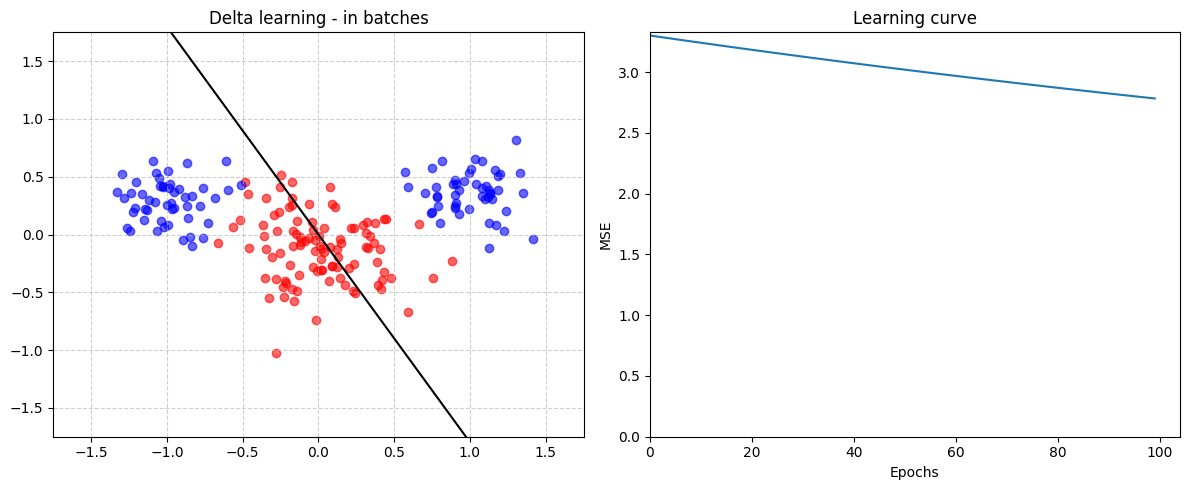

Learning rate: 0.0001


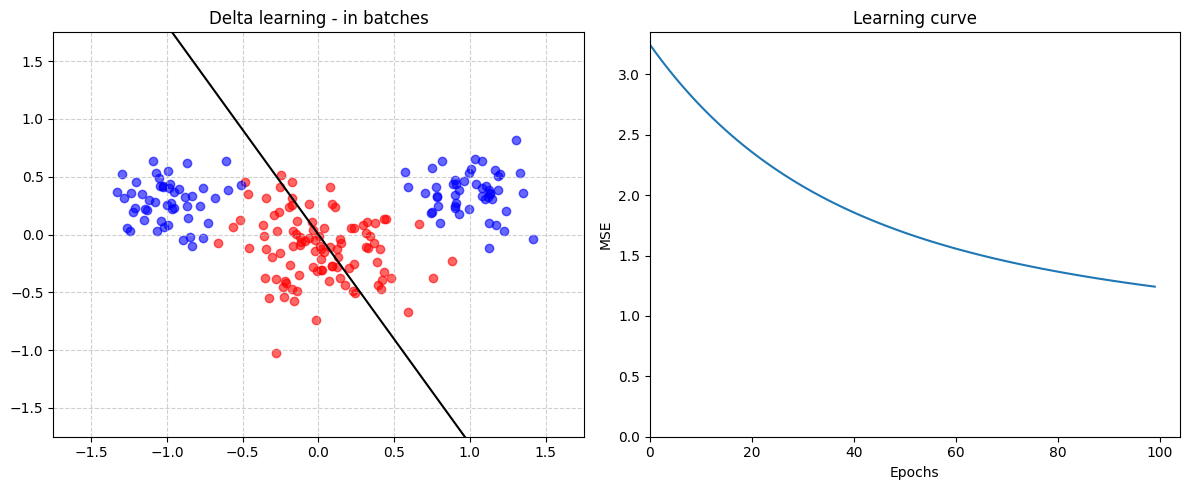

Learning rate: 0.001


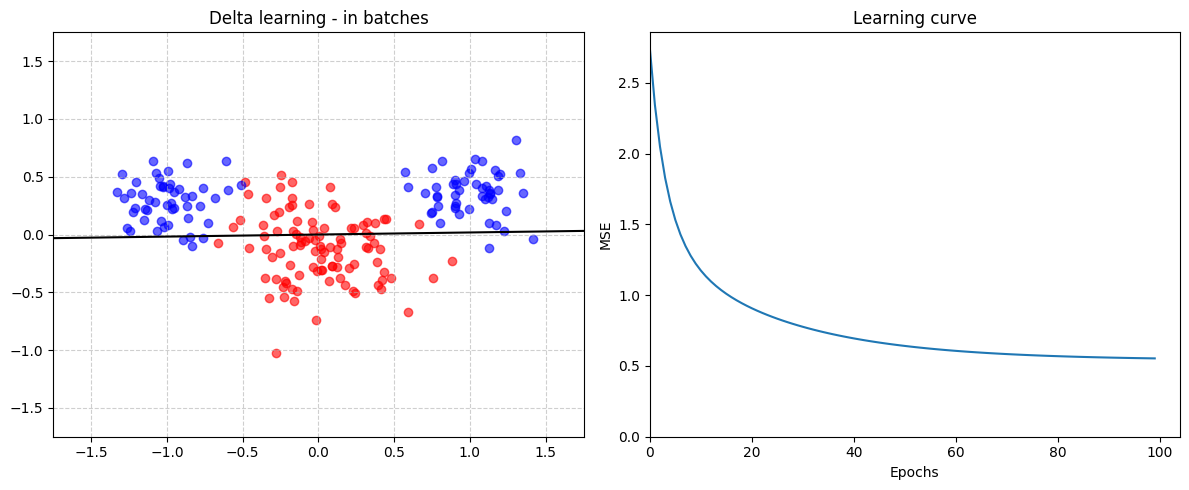

Learning rate: 0.005


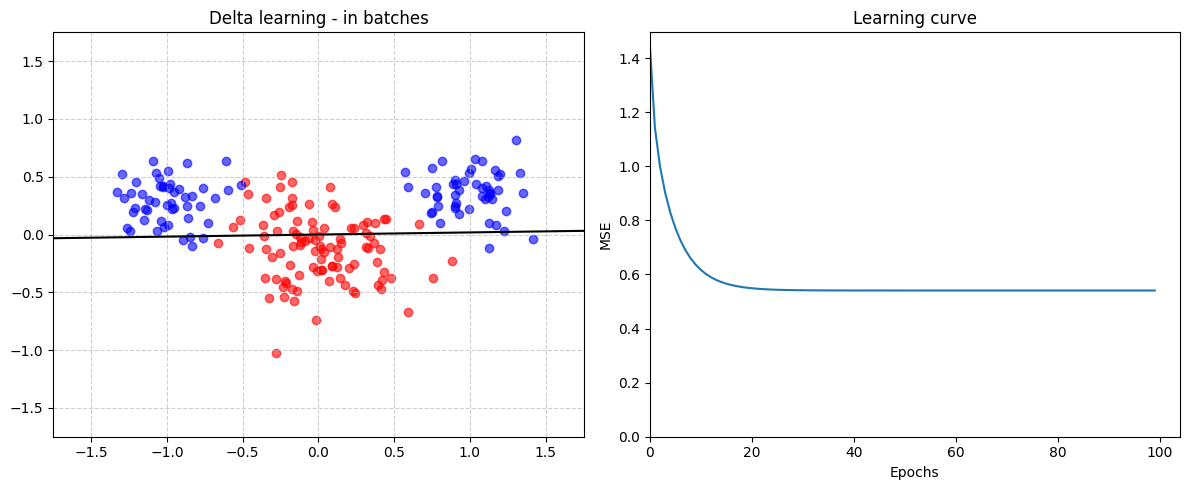

In [24]:
for lr in LRs:
    print(f"Learning rate: {lr}")
    
    w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
     features, labels, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_delta_rule_batch, features, labels, title = "Delta learning - in batches", ax=axes[0], bias=False
    )
    plot_learning_curve(error_history, xlabel = "Epochs", ylabel = "MSE",  ax=axes[1])

    plt.tight_layout()
    plt.show()

#### Training on subsample of Type I.
- Type I. subsample is a subsample of the new linearly inseparable dataset such that random 25% of samples is removed removed both ```classA``` and ```classB```
- perform the perceptron sequential learning rule on the Type I. subsample
- perform the delta learning rule in batch mode on the Type I. subsample

Learning rate: 1e-05


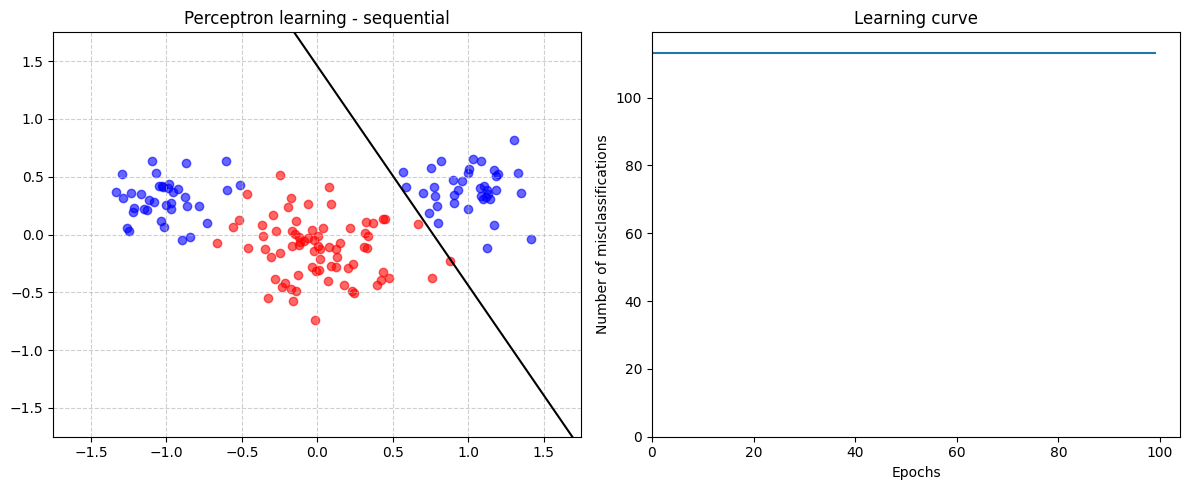

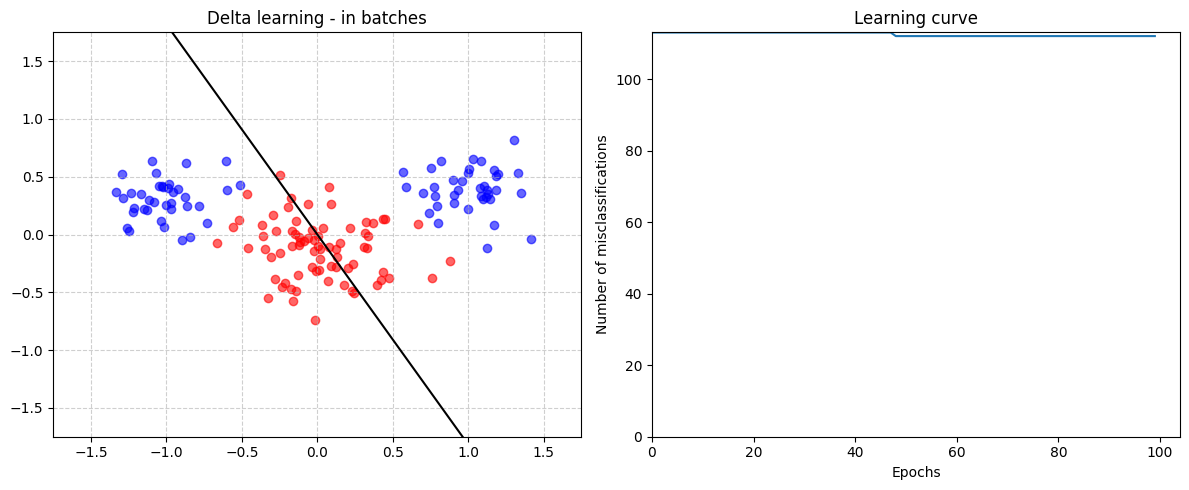

Learning rate: 0.0001


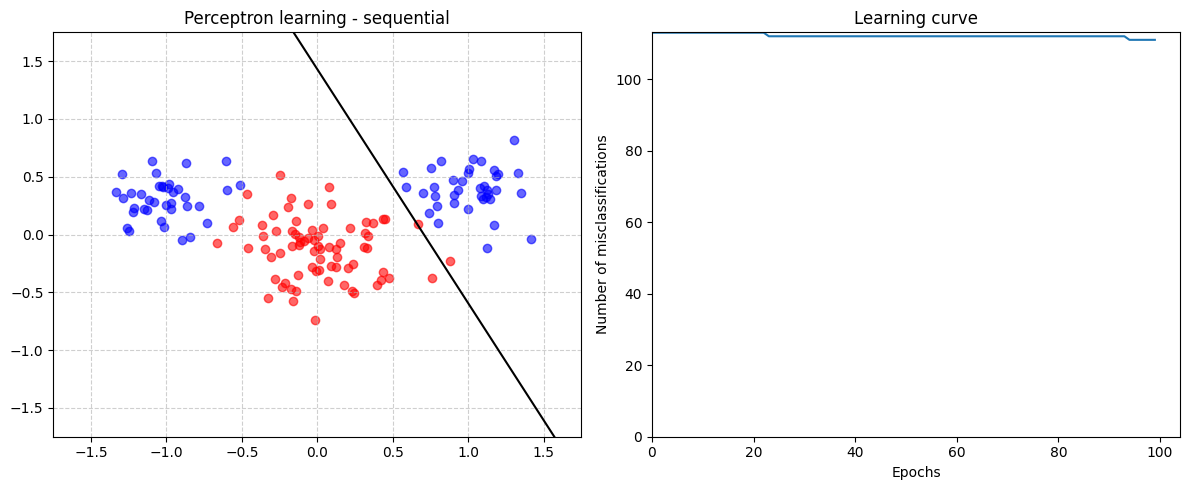

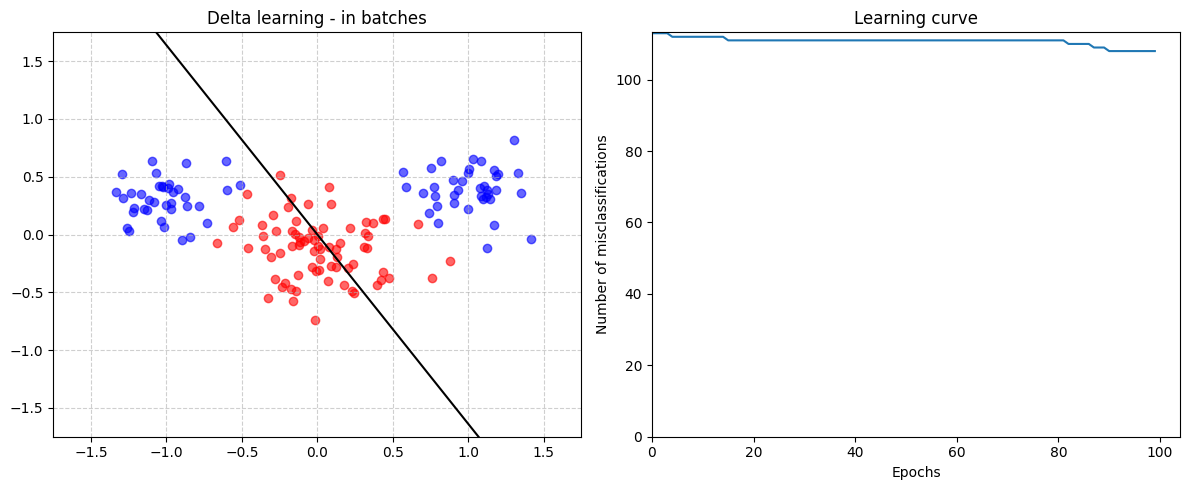

Learning rate: 0.001


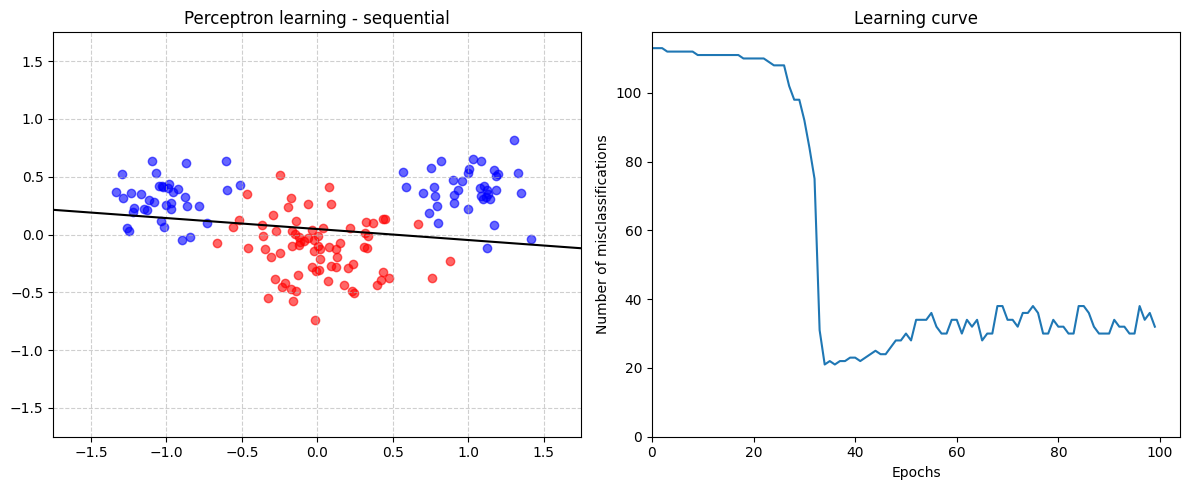

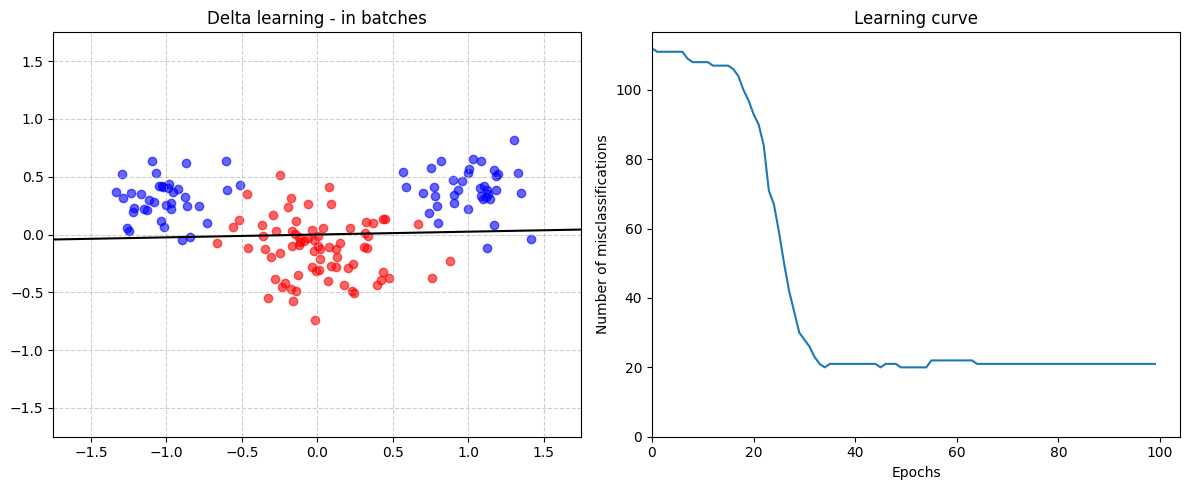

Learning rate: 0.005


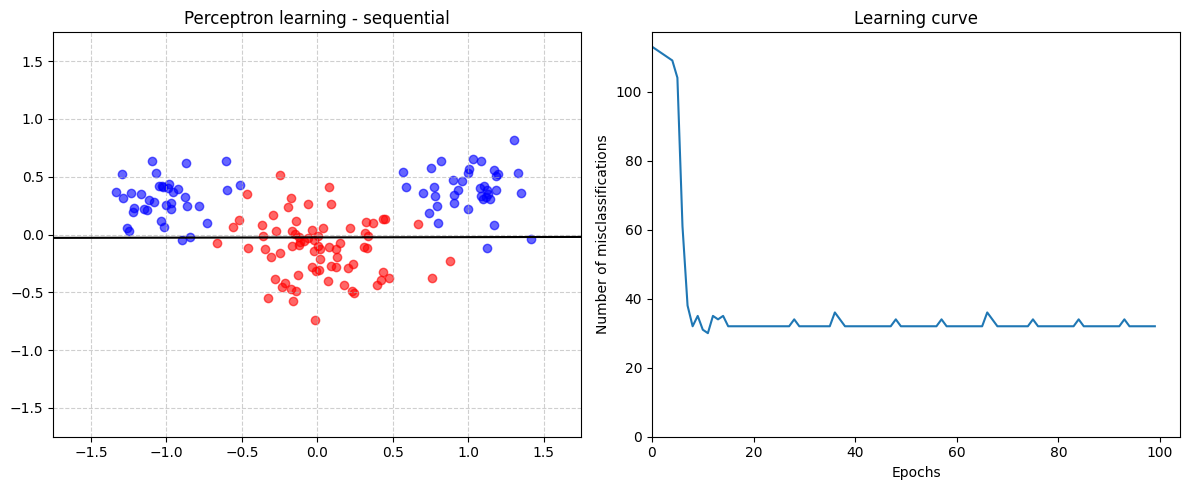

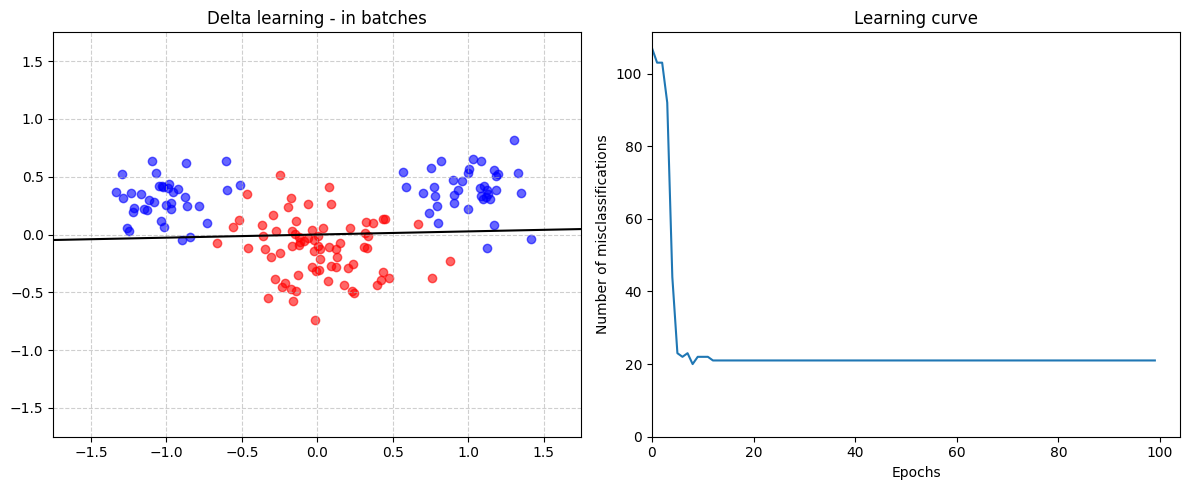

In [25]:
# Create subsamples

sample_size = int(0.75 * N)

random_indices_A = np.random.choice(classA.shape[1], size=sample_size, replace=False)
random_indices_B = np.random.choice(classB.shape[1], size=sample_size, replace=False)

classA_sampled = classA[:, random_indices_A]
classB_sampled = classB[:, random_indices_B]

features_sampled = np.hstack([classA_sampled, classB_sampled])
labels_sampled = np.hstack([np.ones(sample_size), -np.ones(sample_size)])

random_indexes = np.random.permutation(sample_size*2) 
features_sampled, labels_sampled = features_sampled[:, random_indexes], labels_sampled[random_indexes]

features_without_bias = np.array(features_sampled)

bias_row = np.ones((1, features_sampled.shape[1]))
features = np.vstack([features_without_bias, bias_row])


for lr in LRs:
    print(f"Learning rate: {lr}")

    # Perceptrone learnign rule 

    w_perceptron_online, eh_perceptron_online = perceptron_online(
        features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_perceptron_online, features, labels_sampled, title = "Perceptron learning - sequential", ax=axes[0]
    )
    plot_learning_curve(eh_perceptron_online, xlabel = "Epochs", ylabel = "Number of misclassifications", ax=axes[1])

    plt.tight_layout()
    plt.show()

    # Delta learning rule
    
    w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
     features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_delta_rule_batch, features, labels_sampled, title = "Delta learning - in batches", ax=axes[0], bias=False
    )
    plot_learning_curve(misclassified_history, xlabel = "Epochs", ylabel = "Number of misclassifications",  ax=axes[1])

    plt.tight_layout()
    plt.show()

#### Training on subsample of Type II.
- Type II. subsample is a subsample of the new linearly inseparable dataset such that random 50% of samples is removed removed ```classA```
- perform the perceptron sequential learning rule on the Type II. subsample
- perform the delta learning rule in batch mode on the Type II. subsample

Learning rate: 1e-05


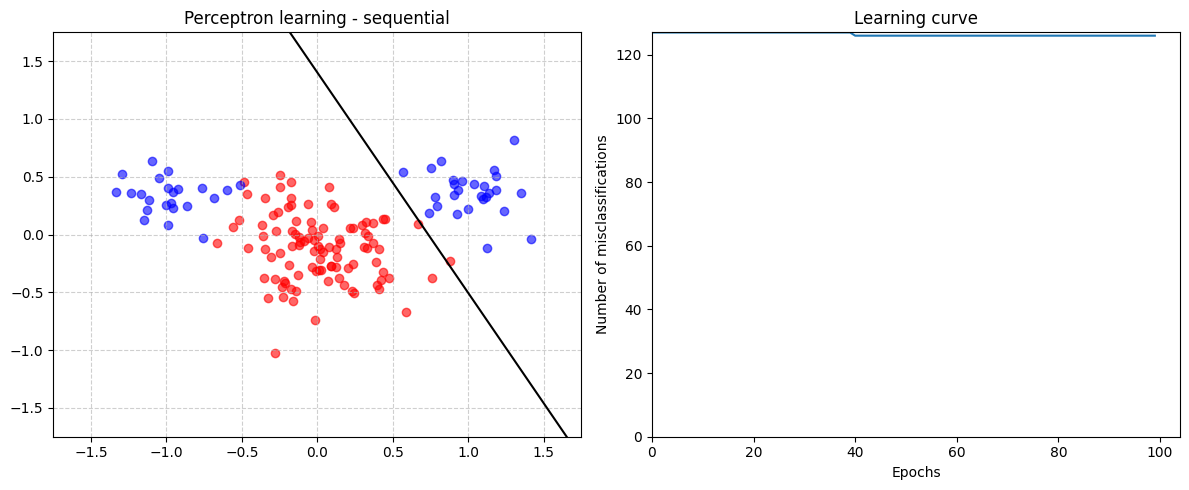

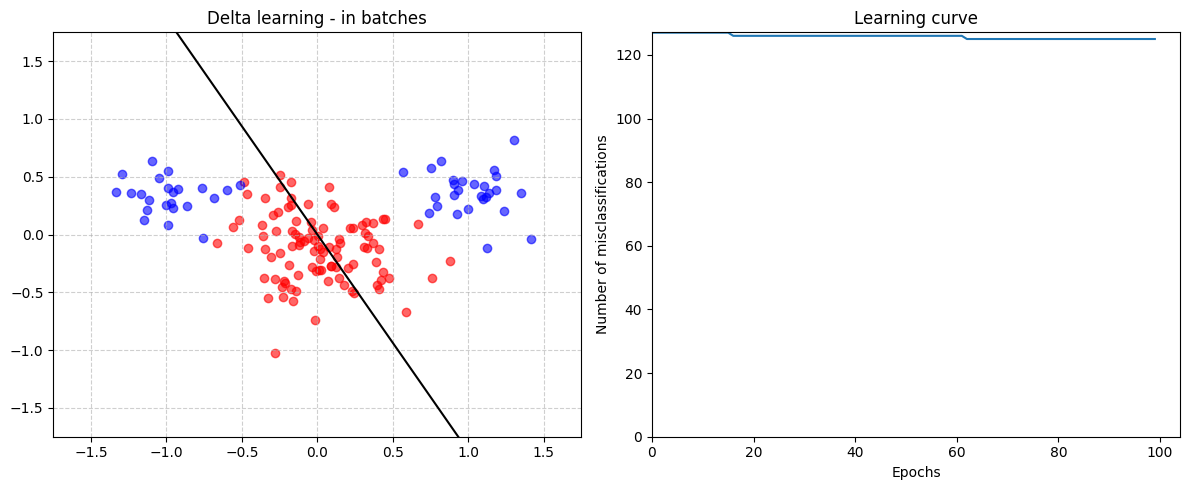

Learning rate: 0.0001


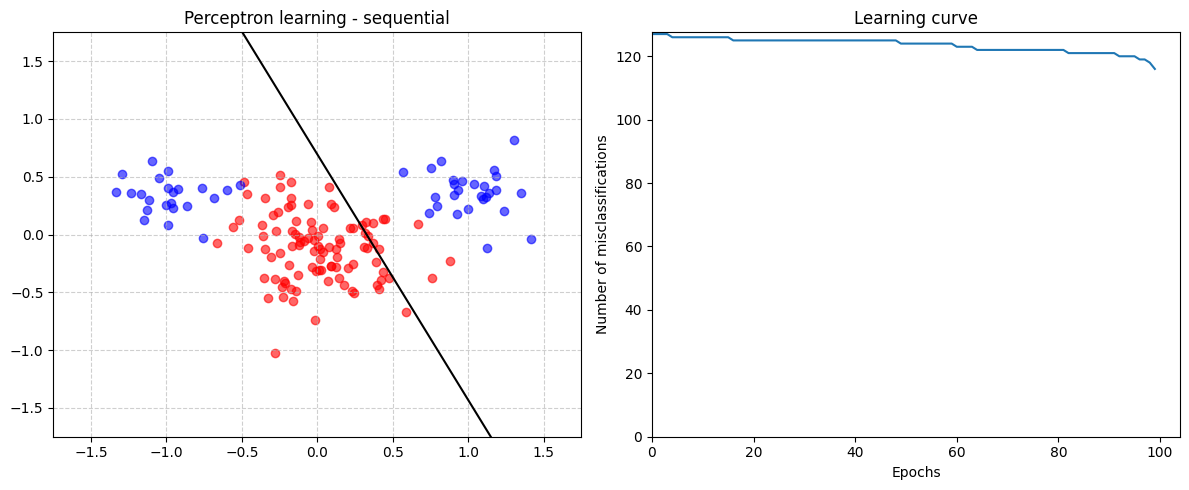

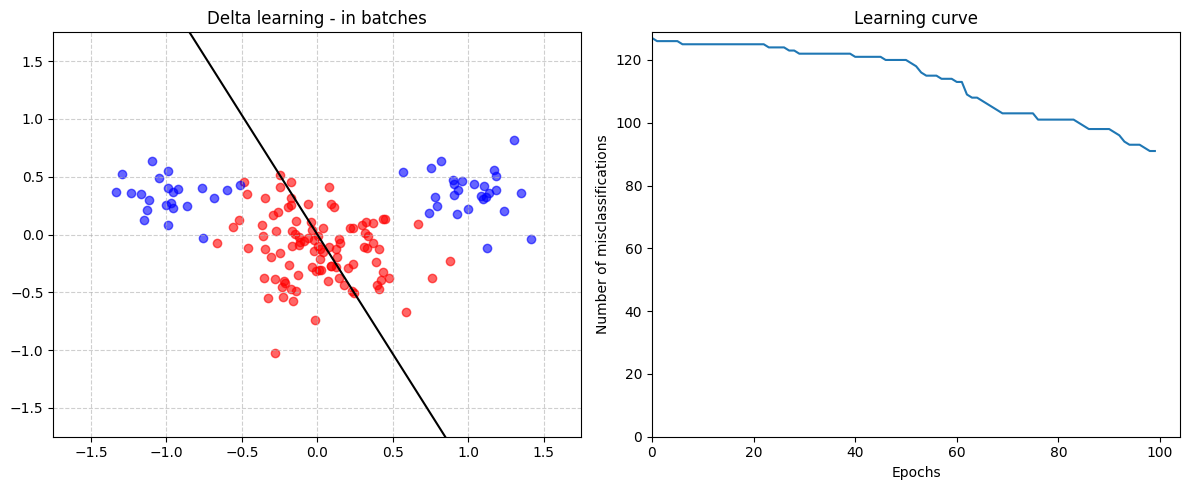

Learning rate: 0.001


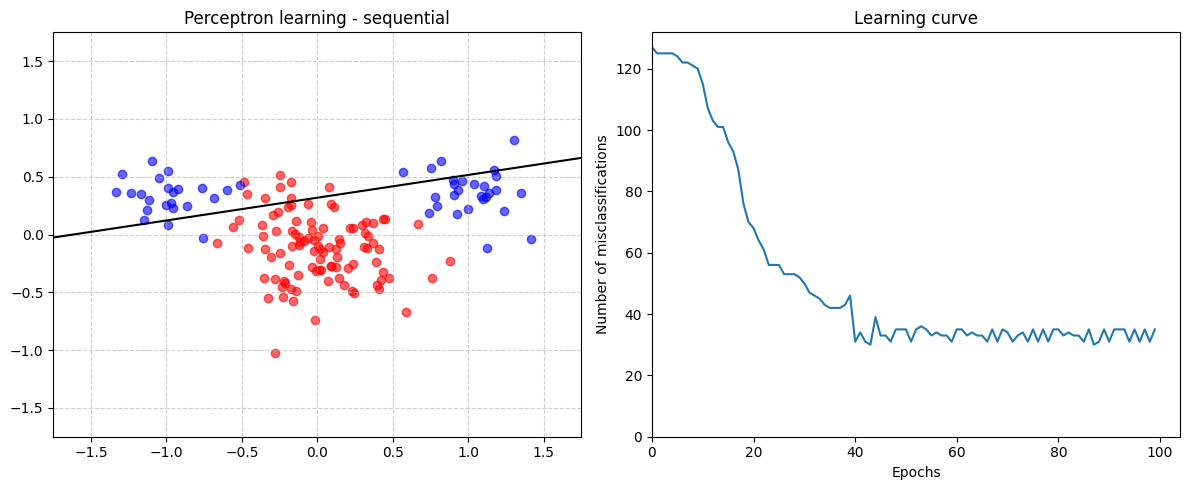

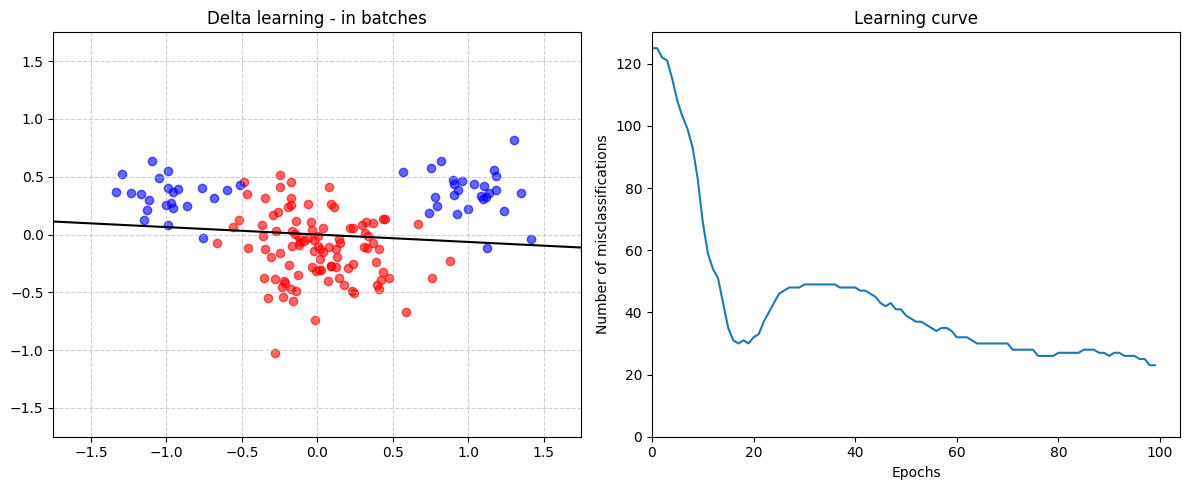

Learning rate: 0.005


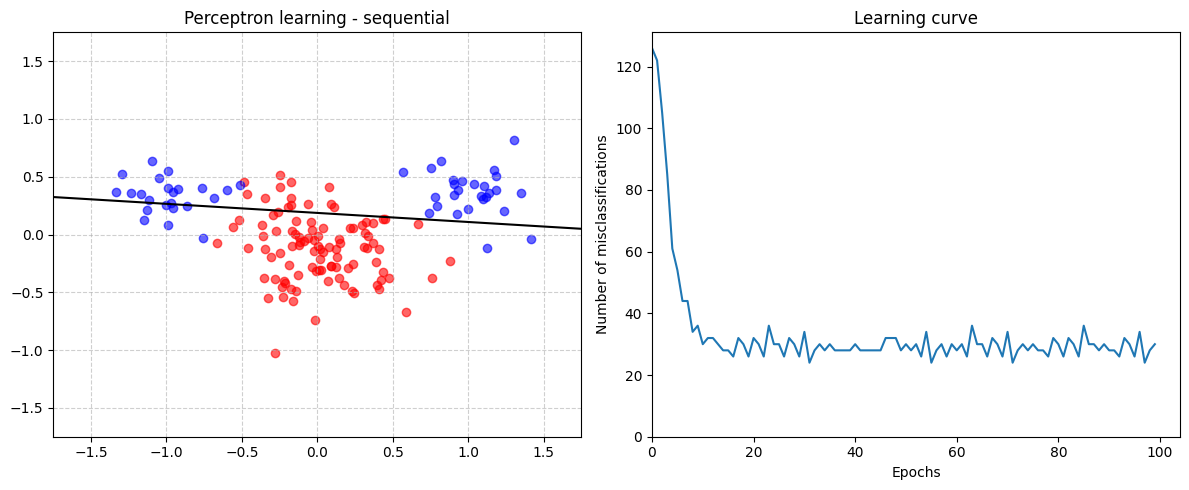

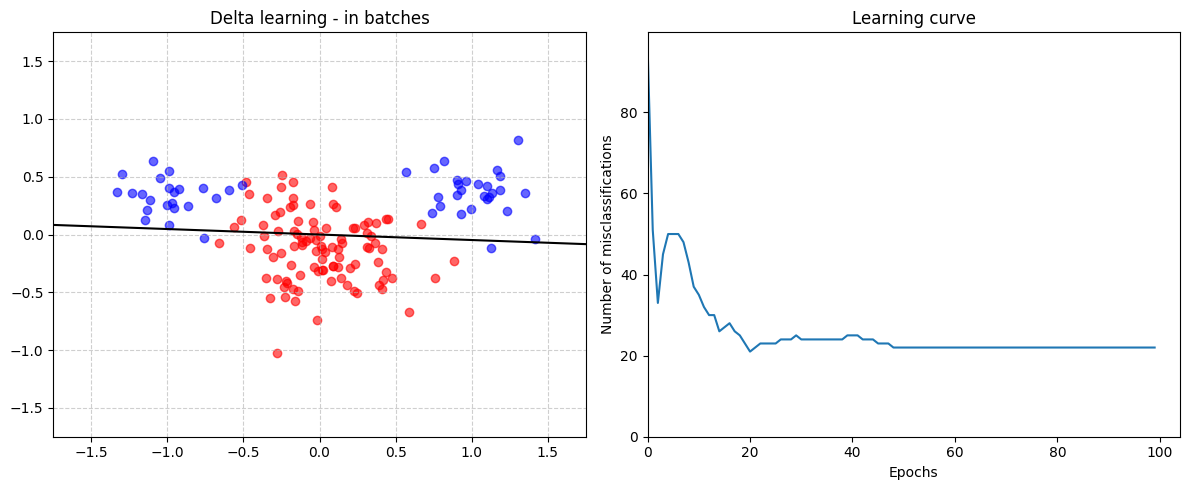

In [26]:
# Create subsamples

sample_size = int(0.5 * N)

random_indices_A = np.random.choice(classA.shape[1], size=sample_size, replace=False)

classA_sampled = classA[:, random_indices_A]

features_sampled = np.hstack([classA_sampled, classB])
labels_sampled = np.hstack([np.ones(sample_size), -np.ones(N)])

random_indexes = np.random.permutation(sample_size + N) 
features_sampled, labels_sampled = features_sampled[:, random_indexes], labels_sampled[random_indexes]

features_without_bias = np.array(features_sampled)

bias_row = np.ones((1, features_sampled.shape[1]))
features = np.vstack([features_without_bias, bias_row])


for lr in LRs:
    print(f"Learning rate: {lr}")

    # Perceptrone learnign rule 

    w_perceptron_online, eh_perceptron_online = perceptron_online(
        features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_perceptron_online, features, labels_sampled, title = "Perceptron learning - sequential", ax=axes[0]
    )
    plot_learning_curve(eh_perceptron_online, xlabel = "Epochs", ylabel = "Number of misclassifications", ax=axes[1])

    plt.tight_layout()
    plt.show()

    # Delta learnign rule
    
    w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
     features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_delta_rule_batch, features, labels_sampled, title = "Delta learning - in batches", ax=axes[0], bias=False
    )
    plot_learning_curve(misclassified_history, xlabel = "Epochs", ylabel = "Number of misclassifications",  ax=axes[1])

    plt.tight_layout()
    plt.show()

#### Training on subsample of Type III.
- Type III. subsample is a subsample of the new linearly inseparable dataset such that random 50% of samples is removed removed ```classB```
- perform the perceptron sequential learning rule on the Type III. subsample
- perform the delta learning rule in batch mode on the Type III. subsample

Learning rate: 1e-05


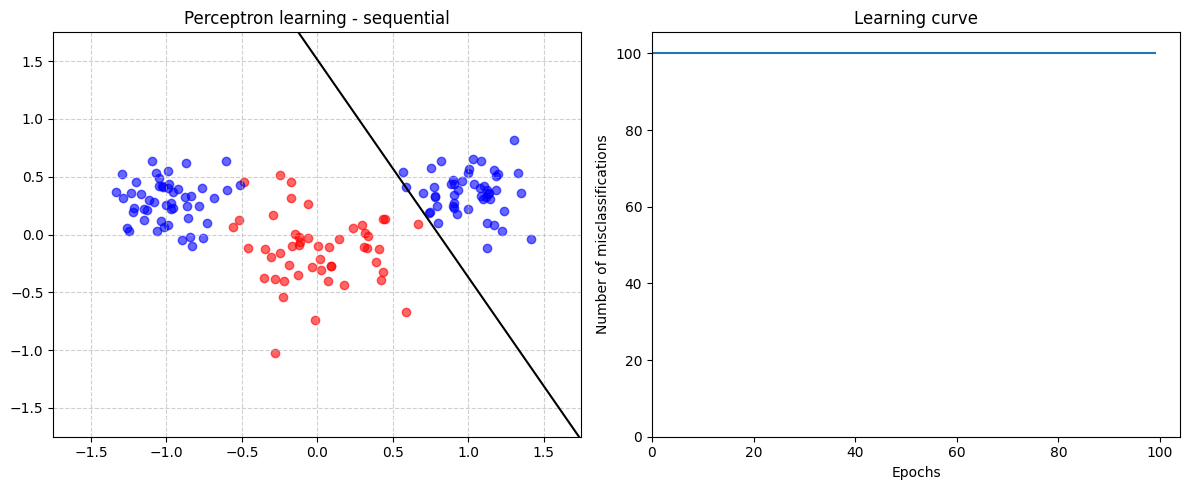

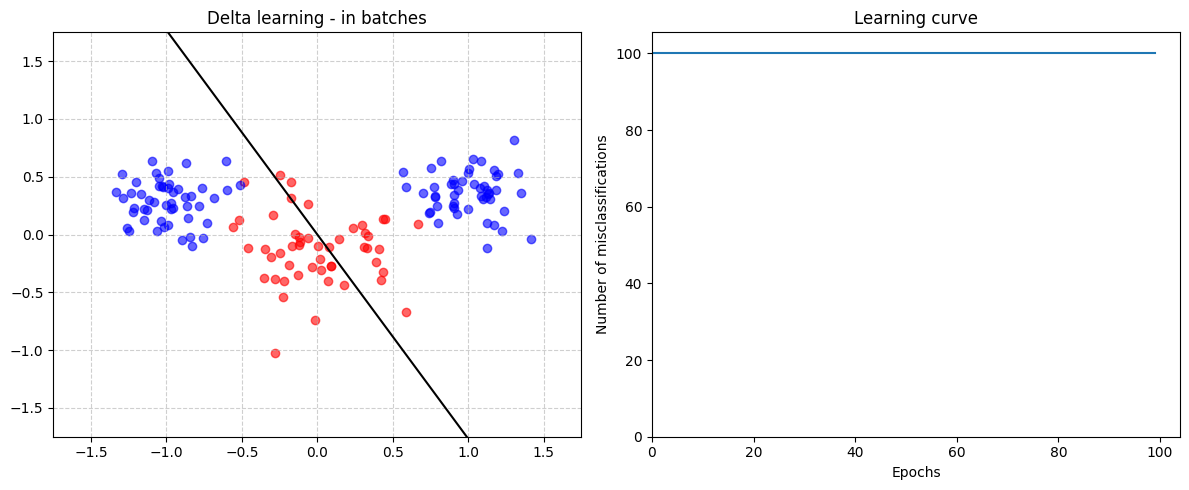

Learning rate: 0.0001


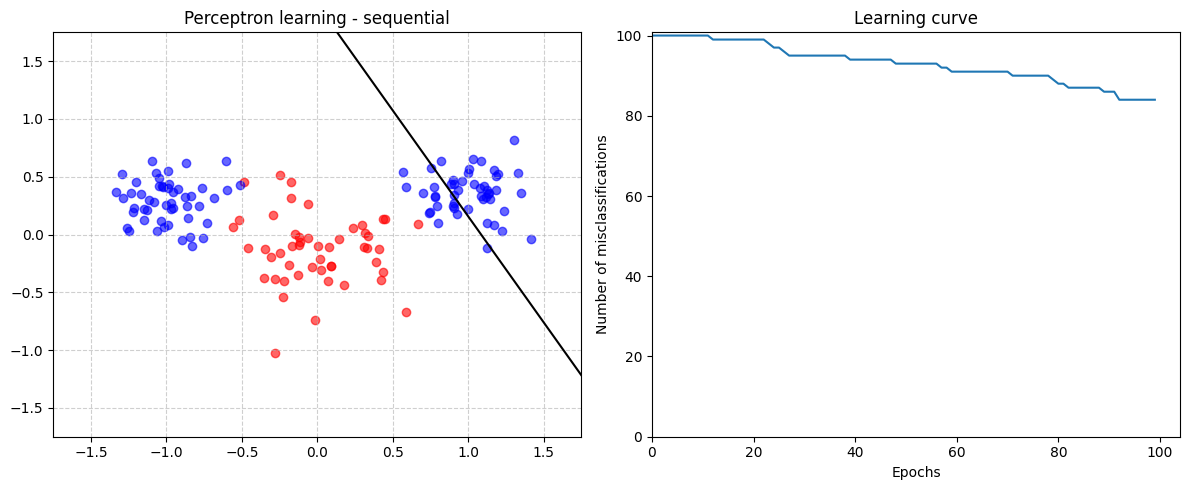

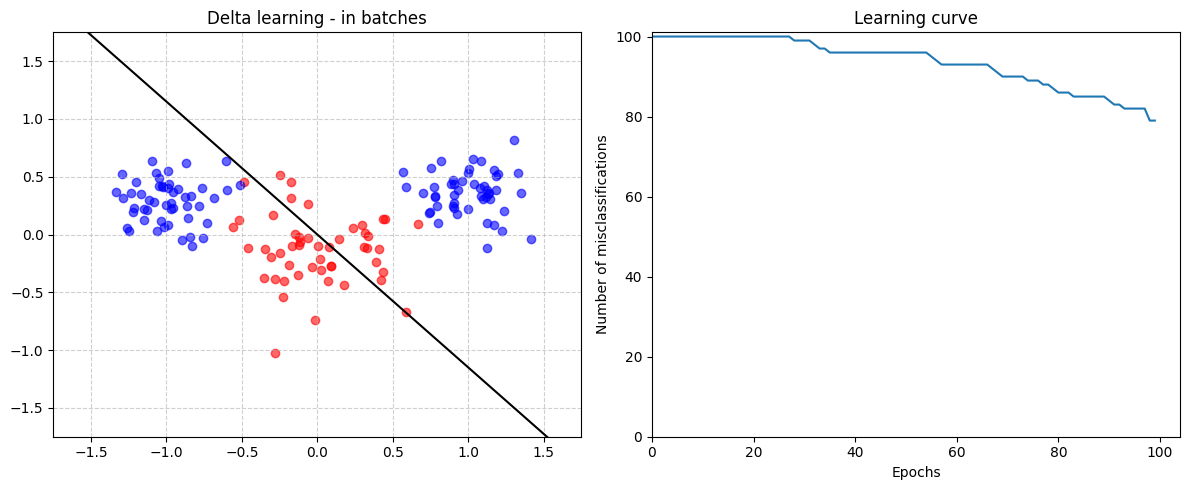

Learning rate: 0.001


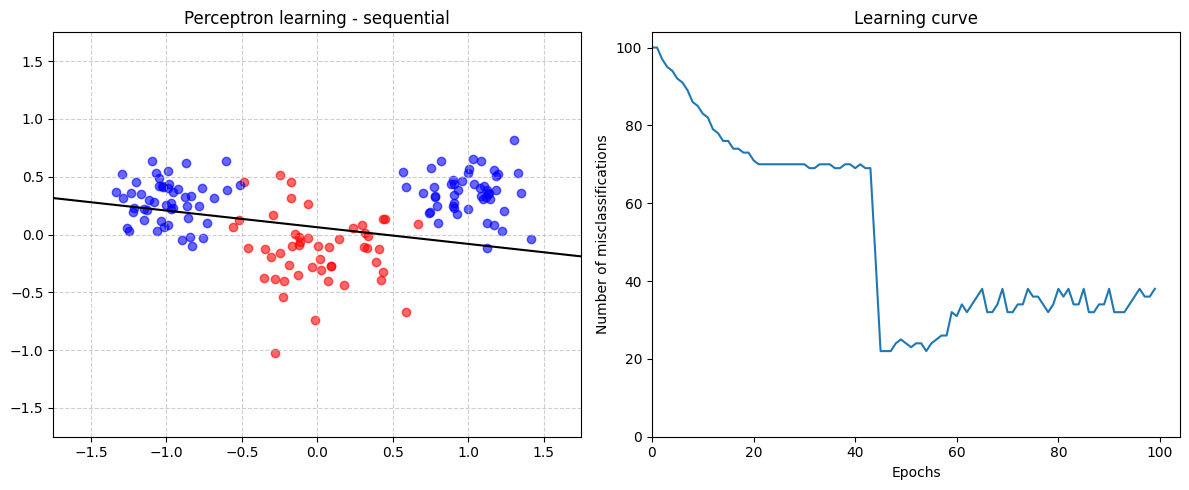

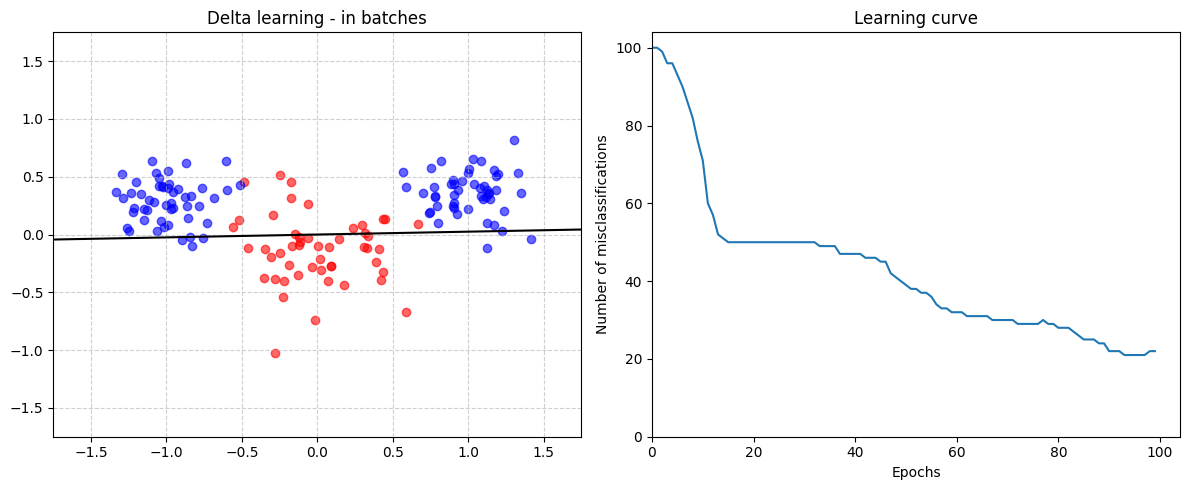

Learning rate: 0.005


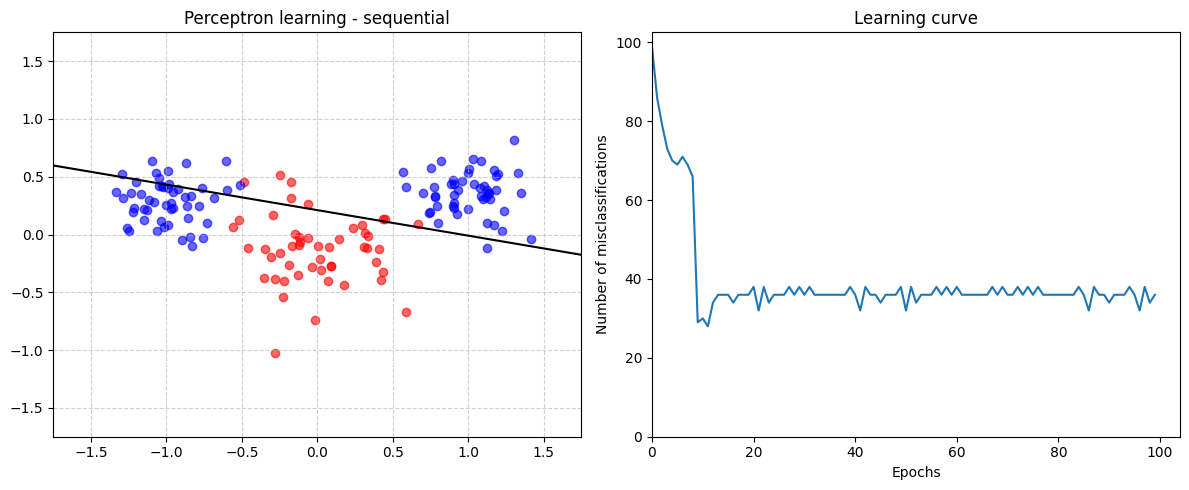

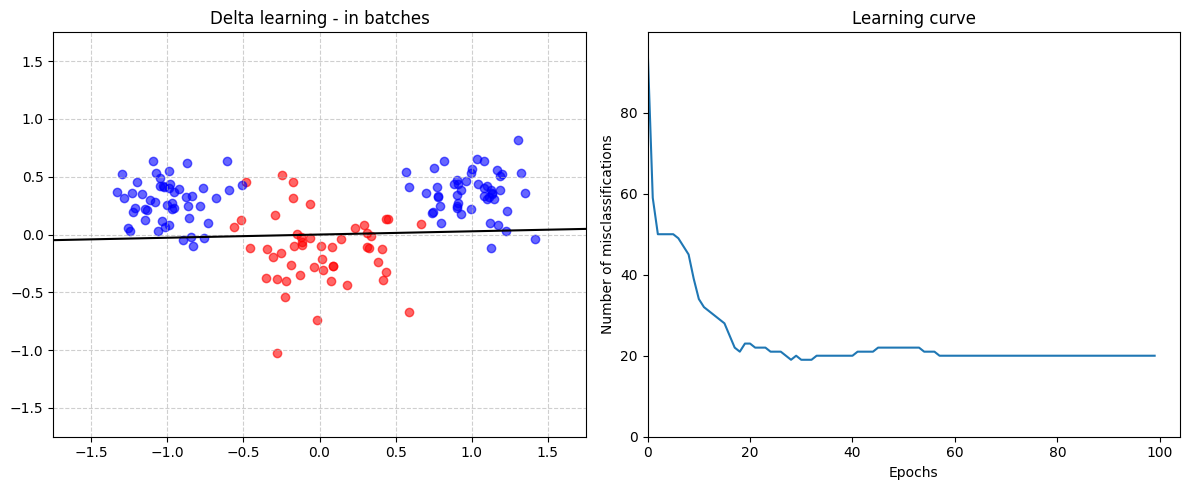

In [27]:
# Create subsamples

sample_size = int(0.5 * N)

random_indices_B = np.random.choice(classB.shape[1], size=sample_size, replace=False)

classB_sampled = classB[:, random_indices_B]

features_sampled = np.hstack([classA, classB_sampled])
labels_sampled = np.hstack([np.ones(N), -np.ones(sample_size)])

random_indexes = np.random.permutation(N + sample_size) 
features_sampled, labels_sampled = features_sampled[:, random_indexes], labels_sampled[random_indexes]

features_without_bias = np.array(features_sampled)

bias_row = np.ones((1, features_sampled.shape[1]))
features = np.vstack([features_without_bias, bias_row])


for lr in LRs:
    print(f"Learning rate: {lr}")

    # Perceptrone learnign rule 

    w_perceptron_online, eh_perceptron_online = perceptron_online(
        features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_perceptron_online, features, labels_sampled, title = "Perceptron learning - sequential", ax=axes[0]
    )
    plot_learning_curve(eh_perceptron_online, xlabel = "Epochs", ylabel = "Number of misclassifications", ax=axes[1])

    plt.tight_layout()
    plt.show()

    # Delta learning rule
    
    w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
     features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_delta_rule_batch, features, labels_sampled, title = "Delta learning - in batches", ax=axes[0], bias=False
    )
    plot_learning_curve(misclassified_history, xlabel = "Epochs", ylabel = "Number of misclassifications",  ax=axes[1])

    plt.tight_layout()
    plt.show()

#### Training on subsample of Type IV.
- Type IV. subsample is a subsample of the new linearly inseparable dataset such that random 20% of data from ```classA``` for which ```classA(1,:)<0``` and random 80% of data from ```classA``` for which ```classA(1,:)>0``` is removed from from ```classA```
- perform the perceptron sequential learning rule on the Type IV. subsample
- perform the delta learning rule in batch mode on the Type IV. subsample

Learning rate: 1e-05


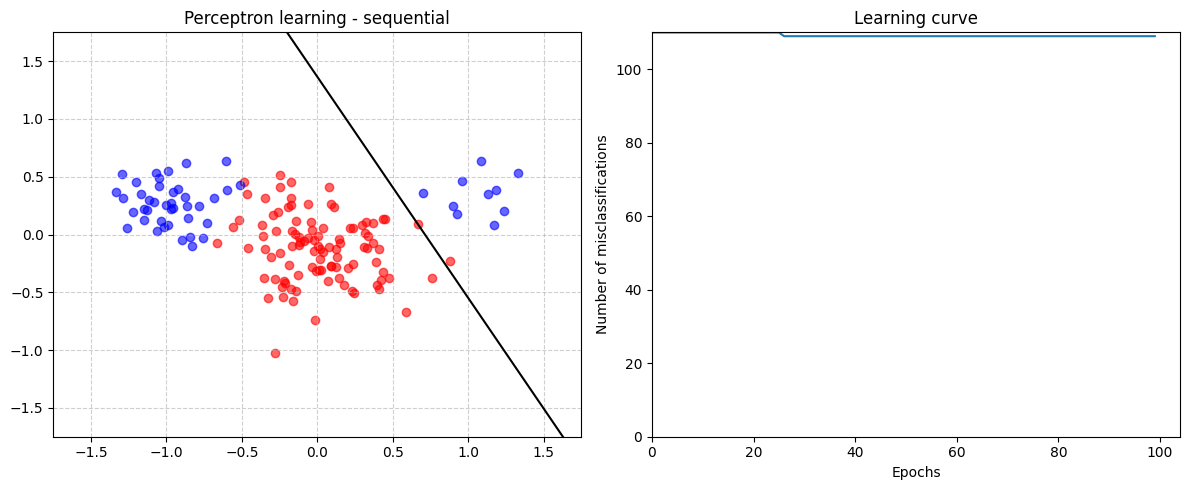

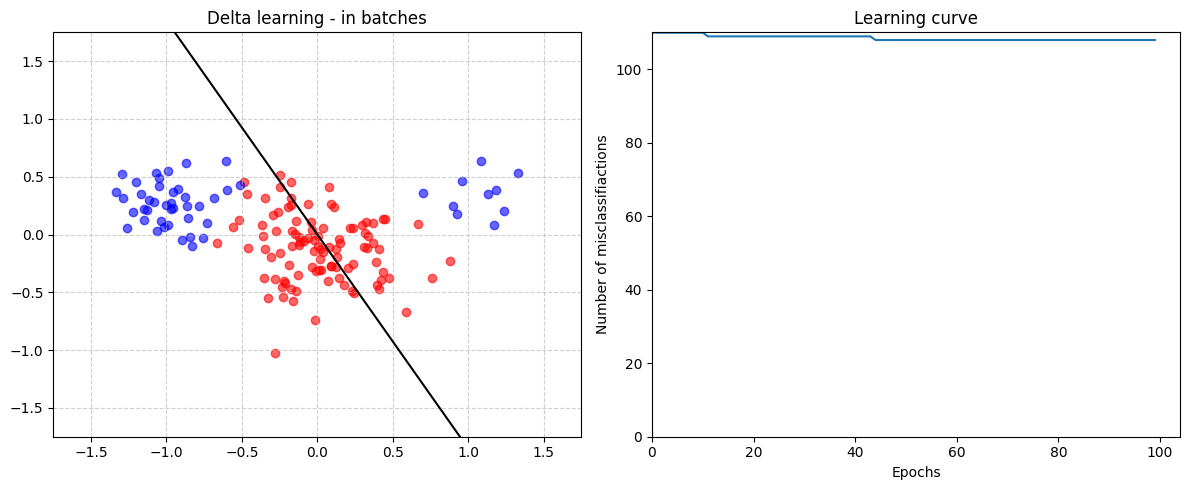

Learning rate: 0.0001


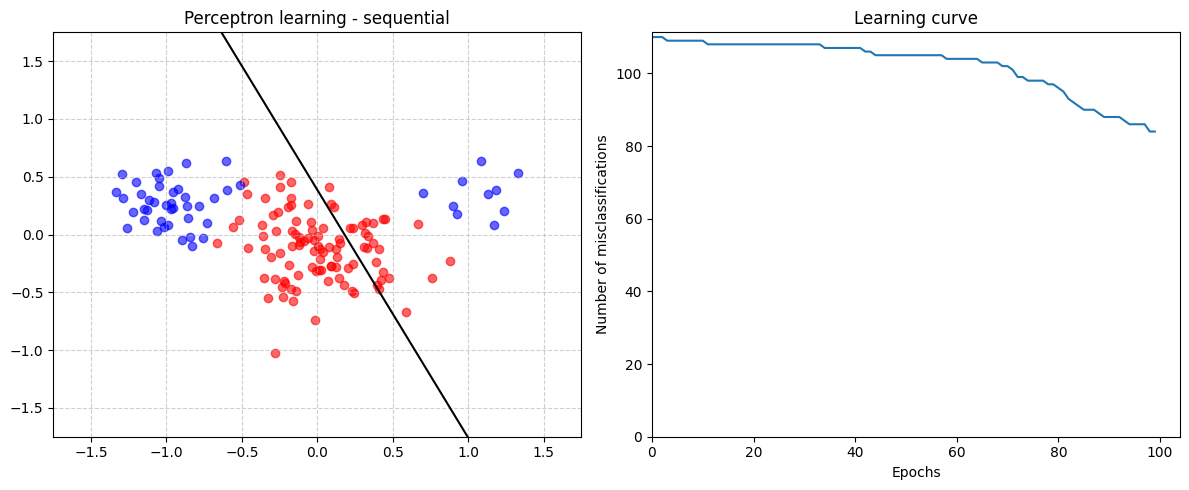

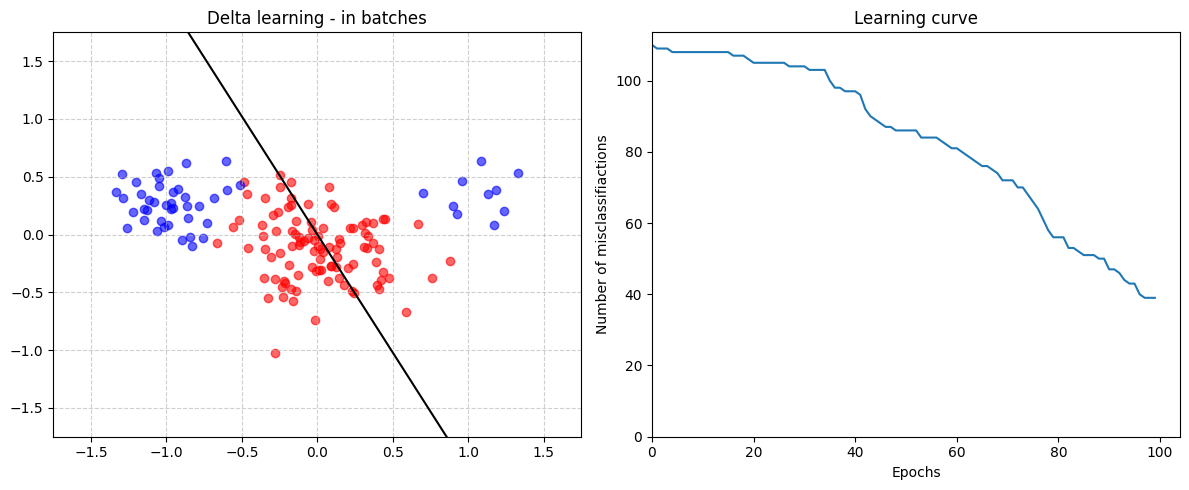

Learning rate: 0.001


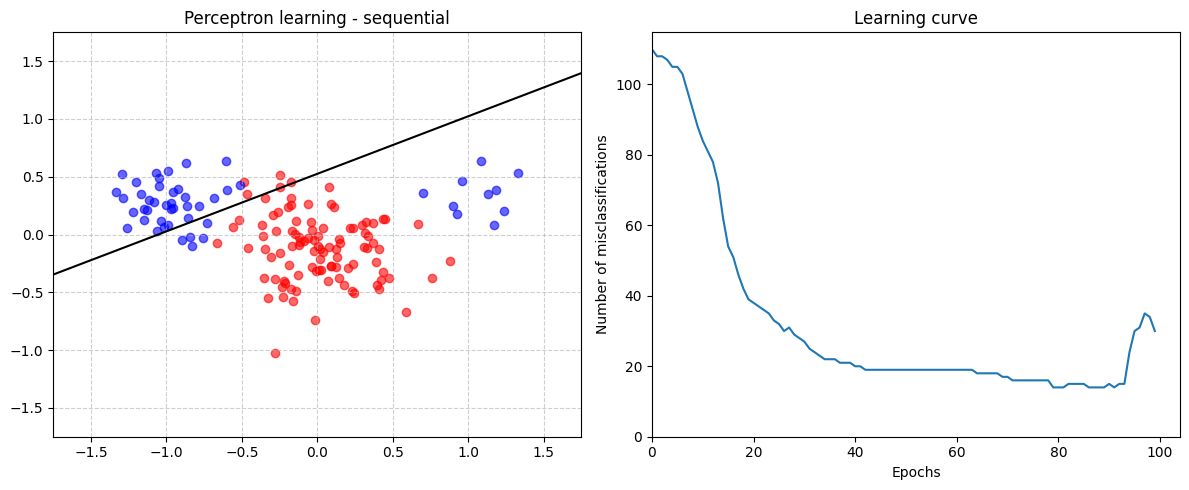

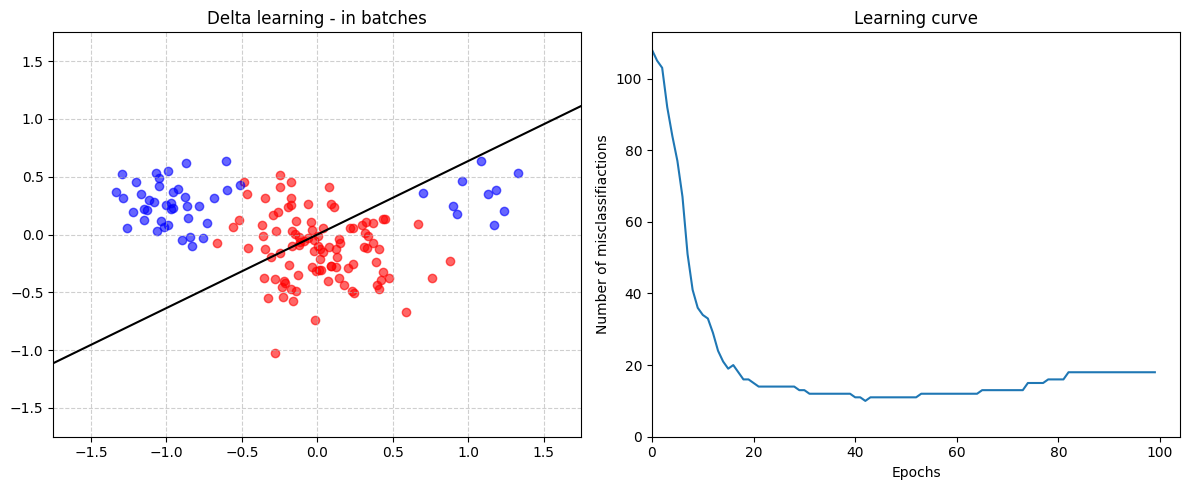

Learning rate: 0.005


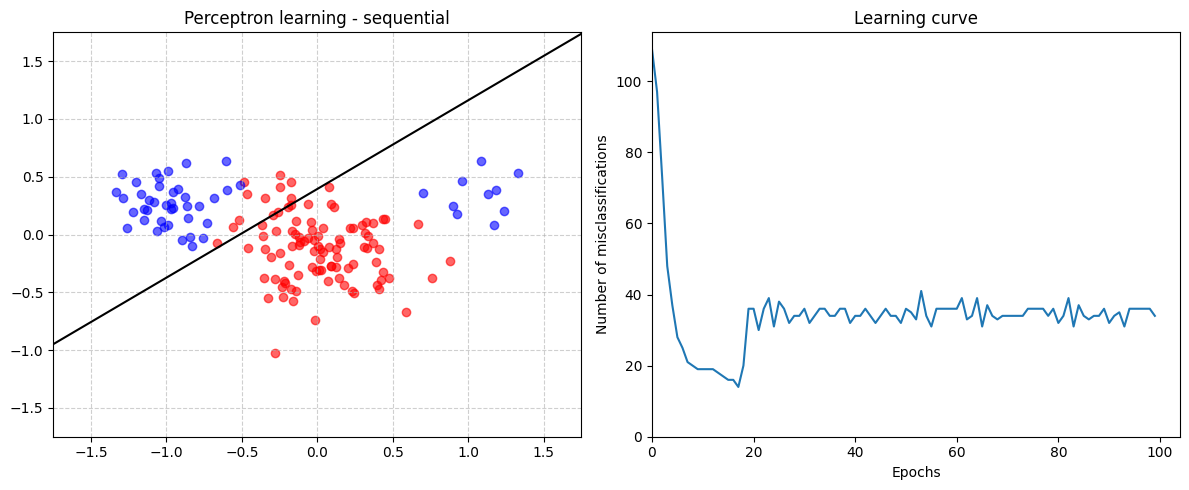

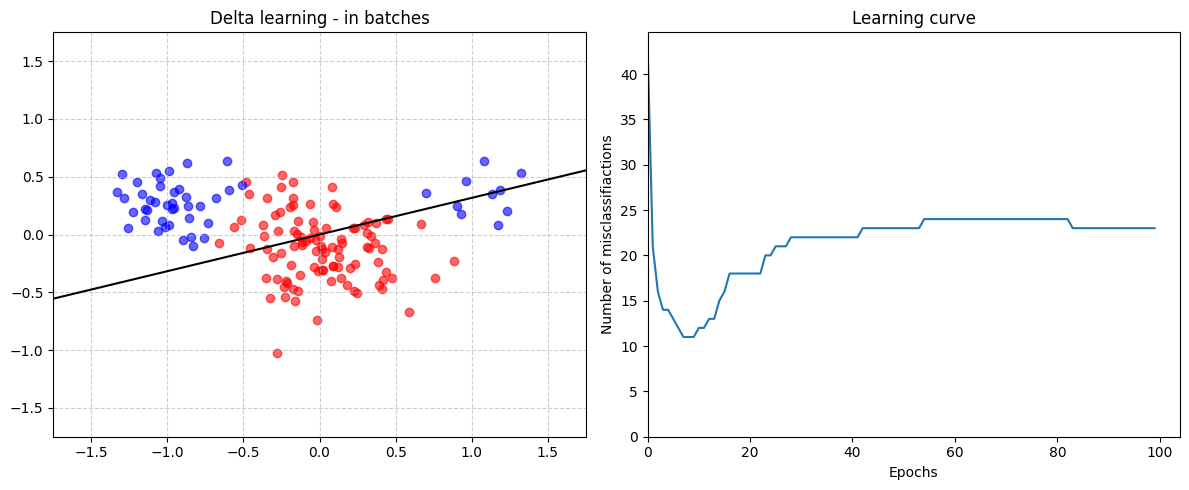

In [28]:

row_idx = 0

subset1_indices = np.where(classA[row_idx, :] < 0)[0]
subset2_indices = np.where(classA[row_idx, :] > 0)[0]

remove_count_sub1 = int(0.2 * len(subset1_indices)) 
remove_count_sub2 = int(0.8 * len(subset2_indices)) 

remove_idx_sub1 = np.random.choice(subset1_indices, size=remove_count_sub1, replace=False)
remove_idx_sub2 = np.random.choice(subset2_indices, size=remove_count_sub2, replace=False)

indices_to_remove = np.concatenate([remove_idx_sub1, remove_idx_sub2])
all_indices = np.arange(classA.shape[1])
indices_to_keep = np.setdiff1d(all_indices, indices_to_remove)

classA_sampled = classA[:, indices_to_keep]

features_sampled = np.hstack([classA_sampled, classB])

labels_sampled = np.hstack([np.ones(classA_sampled.shape[1]), -np.ones(N)])

# Shuffle
total_sampled_size = features_sampled.shape[1]
random_indexes = np.random.permutation(total_sampled_size) 
features_sampled = features_sampled[:, random_indexes]
labels_sampled = labels_sampled[random_indexes]

# Add bias row
bias_row = np.ones((1, total_sampled_size))
features = np.vstack([features_sampled, bias_row])


for lr in LRs:
    print(f"Learning rate: {lr}")

    # Perceptrone learnign rule 

    w_perceptron_online, eh_perceptron_online = perceptron_online(
        features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_perceptron_online, features, labels_sampled, title = "Perceptron learning - sequential", ax=axes[0]
    )
    plot_learning_curve(eh_perceptron_online, xlabel = "Epochs", ylabel = "Number of misclassifications", ax=axes[1])

    plt.tight_layout()
    plt.show()

    # Delta learning rule
    
    w_delta_rule_batch, misclassified_history, error_history = delta_rule_batch(
     features, labels_sampled, weights.copy(), lr=lr, epochs=EPOCHS
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_decision_boundary(
        w_delta_rule_batch, features, labels_sampled, title = "Delta learning - in batches", ax=axes[0], bias=False
    )
    plot_learning_curve(misclassified_history, xlabel = "Epochs", ylabel = "Number of misclassifiactions",  ax=axes[1])

    plt.tight_layout()
    plt.show()